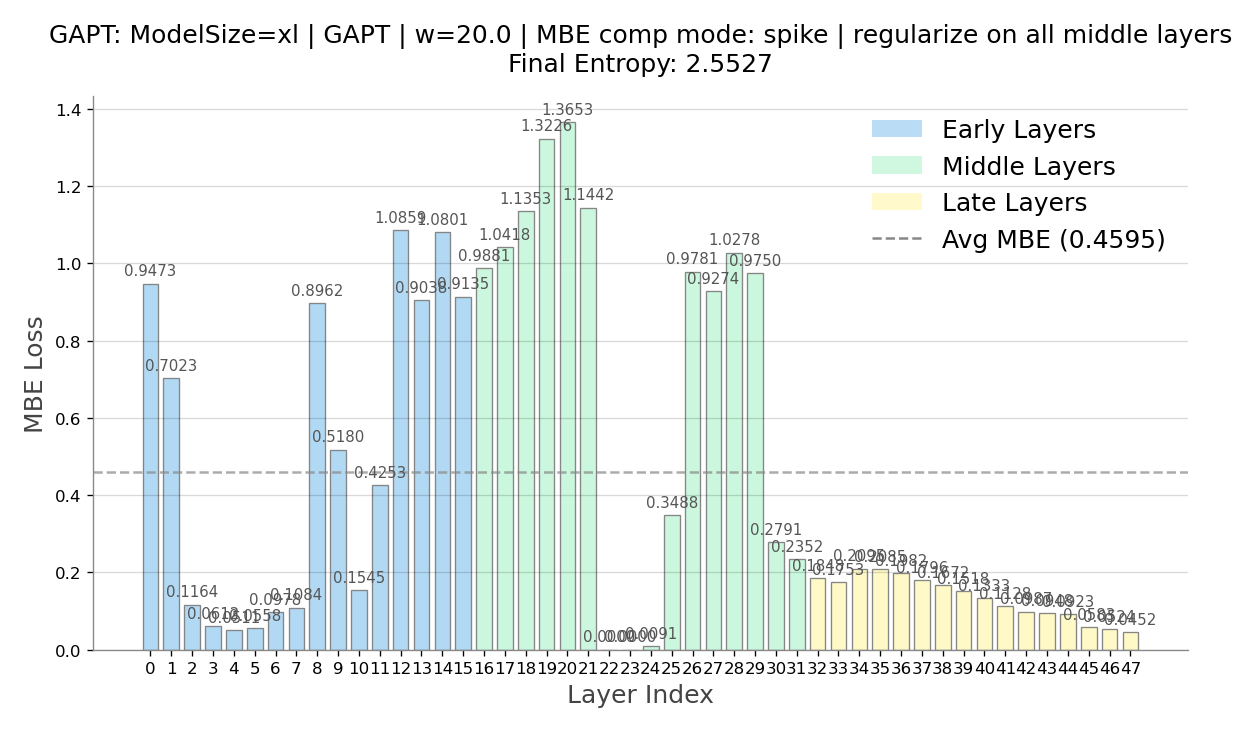

In [37]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/fineweb10B-gpt2-xl-spike.txt"
# log_path = "logs/fineweb10B-gpt2-xl-20k.txt"
# log_path = "logs/gpt2-small-no-skip.txt"
# log_path = "logs/iblm-gpt2-small-no-skip-spike.txt"
# log_path = "logs/fineweb10B-gpt2-xl-20k.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [39]:
# gpt2 small spike: layer 5 bottleneck, layer 10 next
# gpt2 medium spike: layer 11 bottleneck, layer 15 next
# gpt2 large spike (softplus): layer 3, next layer 16 & layer 2
# gpt2 xl spike: layer 22 next layer 23

In [9]:
# GAPT w. spike mode bottleneck layer MBE is this small, it must've been "skipping" the layer, instead of propagating through it?
3.8061291434132727e-06 

(0.033 - 3.8061291434132727e-06 ) / 0.033


0.9998846627532298

In [ ]:
from src.prune import prune_layer

def local_load_ckpt(model, ckpt_path):
    """load compiled ckpt locally"""
    model_ckpt = torch.load(ckpt_path, map_location="cpu")['model']
    clean_state_dict = {k.replace("_orig_mod.", ""): v for k, v in model_ckpt.items()}
    model.load_state_dict(clean_state_dict)
    return model

ckpt_path = "ckpt/fineweb10B-gpt2-small-spike.pt"

from src.gapt import GPT, GPTConfig

gpt_config = GPTConfig.prior("small")
base_model = GPT(gpt_config)
base_model = local_load_ckpt(base_model, ckpt_path)

# --- when we have a prior belief on which layer to prune, pruning is replacing layer with identity block ---
prune_layer(base_model, [5])



🔧 Pruned layers: [5]


small_gapt_from_gapt_shard8_20260112_020936.txt -> {'method': 'gapt', 'ckpt_source': 'gapt', 'shard': 8}
small_gapt_softplus_from_gapt_shard2_20260111_203124.txt -> {'method': 'gapt_softplus', 'ckpt_source': 'gapt', 'shard': 2}
small_baseline_from_base_shard4_20260111_115339.txt -> {'method': 'baseline', 'ckpt_source': 'base', 'shard': 4}
Parsed 60 log files

=== Forgetting Analysis Summary ===
                          learning         avg_forgetting        
                              mean     std           mean     std
method        ckpt_source                                        
baseline      base          0.3931  0.0061         0.2056  0.0054
              gapt          0.3760  0.0017         0.2022  0.0025
gapt          base          0.3705  0.0056         0.1891  0.0050
              gapt          0.3738  0.0018         0.1994  0.0035
gapt_softplus base          0.3702  0.0054         0.1886  0.0056
              gapt          0.3740  0.0020         0.2001  0.0036


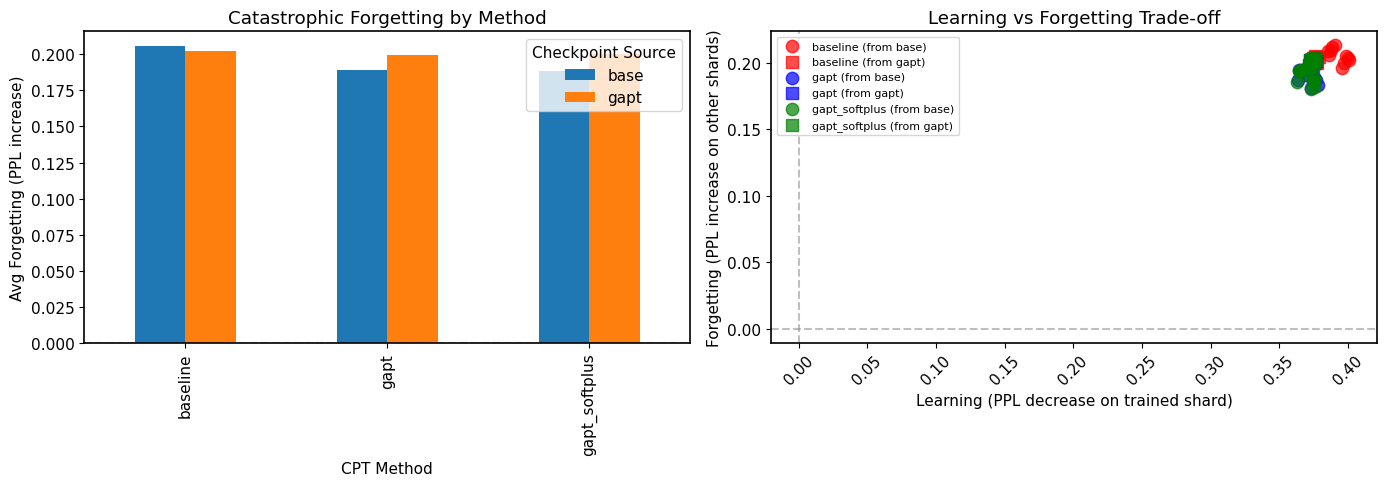


=== Key Findings ===
Baseline forgetting (from base):      0.2056
GAPT forgetting (from base):          0.1891
GAPT+softplus forgetting (from base): 0.1886

GAPT reduces forgetting by: 8.0%
GAPT+softplus reduces forgetting by: 8.2%


In [14]:
# Analyze 'forget alleviation'

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ============================================
# Parse log files
# ============================================
log_dir = Path("logs/forget-log")

def parse_log_file(filepath):
    """Extract final PPL per bin and loss trajectories from log file."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract final PPL line: [bin0 ppl: 2.5715] [bin1 ppl: 3.1731] ...
    ppl_pattern = r'\[bin(\d+) ppl: ([\d.]+)\]'
    ppl_matches = re.findall(ppl_pattern, content)
    final_ppl = {f'bin{m[0]}': float(m[1]) for m in ppl_matches}
    
    # Extract loss record dict
    loss_pattern = r"'val_bin(\d+)_entropy': \[([\d., ]+)\]"
    loss_matches = re.findall(loss_pattern, content)
    loss_trajectories = {}
    for m in loss_matches:
        bin_id = int(m[0])
        losses = [float(x.strip()) for x in m[1].split(',')]
        loss_trajectories[f'bin{bin_id}'] = losses
    
    # Extract which shard was trained on
    train_shard_match = re.search(r'train_files.*bin(\d+)', content)
    train_shard = int(train_shard_match.group(1)) if train_shard_match else None
    
    return {
        'final_ppl': final_ppl,
        'loss_trajectories': loss_trajectories,
        'train_shard': train_shard
    }

def parse_filename(filename):
    """Parse method, ckpt_source, shard from filename."""
    # Pattern: small_{method}_from_{source}_shard{n}_{timestamp}.txt
    # Fix: use non-greedy matching and handle underscore in timestamp
    pattern = r'small_(.+?)_from_(.+?)_shard(\d+)_\d+_\d+\.txt'
    match = re.match(pattern, filename)
    if match:
        return {
            'method': match.group(1),
            'ckpt_source': match.group(2),
            'shard': int(match.group(3))
        }
    return None

# Debug: check what's being parsed
for log_file in list(log_dir.glob("*.txt"))[:3]:
    print(f"{log_file.name} -> {parse_filename(log_file.name)}")

# Parse all logs
results = []
for log_file in log_dir.glob("*.txt"):
    meta = parse_filename(log_file.name)
    if meta is None:
        continue
    data = parse_log_file(log_file)
    results.append({**meta, **data})

print(f"Parsed {len(results)} log files")

# ============================================
# Compute forgetting metrics
# ============================================
def compute_forgetting(result):
    """
    Forgetting = avg PPL increase on non-trained shards.
    Learning = PPL decrease on trained shard.
    """
    train_shard = result['train_shard']
    final_ppl = result['final_ppl']
    trajectories = result['loss_trajectories']
    
    # Initial PPL (first validation step)
    initial_ppl = {k: v[0] if v else None for k, v in trajectories.items()}
    
    # PPL on trained shard
    train_bin = f'bin{train_shard}'
    train_ppl_init = initial_ppl.get(train_bin)
    train_ppl_final = final_ppl.get(train_bin)
    learning = train_ppl_init - train_ppl_final if train_ppl_init and train_ppl_final else 0
    
    # PPL on other shards (forgetting)
    forget_deltas = []
    for bin_id in range(10):
        bin_key = f'bin{bin_id}'
        if bin_id == train_shard:
            continue
        init = initial_ppl.get(bin_key)
        final = final_ppl.get(bin_key)
        if init and final:
            forget_deltas.append(final - init)  # positive = forgetting
    
    avg_forgetting = np.mean(forget_deltas) if forget_deltas else 0
    
    return {
        'learning': learning,
        'avg_forgetting': avg_forgetting,
        'forget_deltas': forget_deltas
    }

# Add metrics to results
for r in results:
    metrics = compute_forgetting(r)
    r.update(metrics)

# ============================================
# Aggregate by method
# ============================================
df = pd.DataFrame(results)
summary = df.groupby(['method', 'ckpt_source']).agg({
    'learning': ['mean', 'std'],
    'avg_forgetting': ['mean', 'std']
}).round(4)

print("\n=== Forgetting Analysis Summary ===")
print(summary)

# ============================================
# Visualization
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of avg forgetting by method
ax1 = axes[0]
methods = df.groupby(['method', 'ckpt_source'])['avg_forgetting'].mean().unstack()
methods.plot(kind='bar', ax=ax1, capsize=4)
ax1.set_ylabel('Avg Forgetting (PPL increase)')
ax1.set_xlabel('CPT Method')
ax1.set_title('Catastrophic Forgetting by Method')
ax1.legend(title='Checkpoint Source')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Plot 2: Learning vs Forgetting trade-off
ax2 = axes[1]
colors = {'baseline': 'red', 'gapt': 'blue', 'gapt_softplus': 'green'}
markers = {'base': 'o', 'gapt': 's'}

for (method, ckpt_source), group in df.groupby(['method', 'ckpt_source']):
    ax2.scatter(
        group['learning'], 
        group['avg_forgetting'],
        c=colors.get(method, 'gray'),
        marker=markers.get(ckpt_source, 'o'),
        label=f'{method} (from {ckpt_source})',
        alpha=0.7,
        s=80
    )

ax2.set_xlabel('Learning (PPL decrease on trained shard)')
ax2.set_ylabel('Forgetting (PPL increase on other shards)')
ax2.set_title('Learning vs Forgetting Trade-off')
ax2.legend(loc='upper left', fontsize=8)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('forgetting_analysis.png', dpi=150)
plt.show()

# ============================================
# Print key findings
# ============================================
print("\n=== Key Findings ===")
baseline_from_base = df[(df['method'] == 'baseline') & (df['ckpt_source'] == 'base')]['avg_forgetting'].mean()
gapt_from_base = df[(df['method'] == 'gapt') & (df['ckpt_source'] == 'base')]['avg_forgetting'].mean()
gapt_softplus_from_base = df[(df['method'] == 'gapt_softplus') & (df['ckpt_source'] == 'base')]['avg_forgetting'].mean()

print(f"Baseline forgetting (from base):      {baseline_from_base:.4f}")
print(f"GAPT forgetting (from base):          {gapt_from_base:.4f}")
print(f"GAPT+softplus forgetting (from base): {gapt_softplus_from_base:.4f}")

if baseline_from_base > 0:
    reduction_gapt = (baseline_from_base - gapt_from_base) / baseline_from_base * 100
    reduction_softplus = (baseline_from_base - gapt_softplus_from_base) / baseline_from_base * 100
    print(f"\nGAPT reduces forgetting by: {reduction_gapt:.1f}%")
    print(f"GAPT+softplus reduces forgetting by: {reduction_softplus:.1f}%")

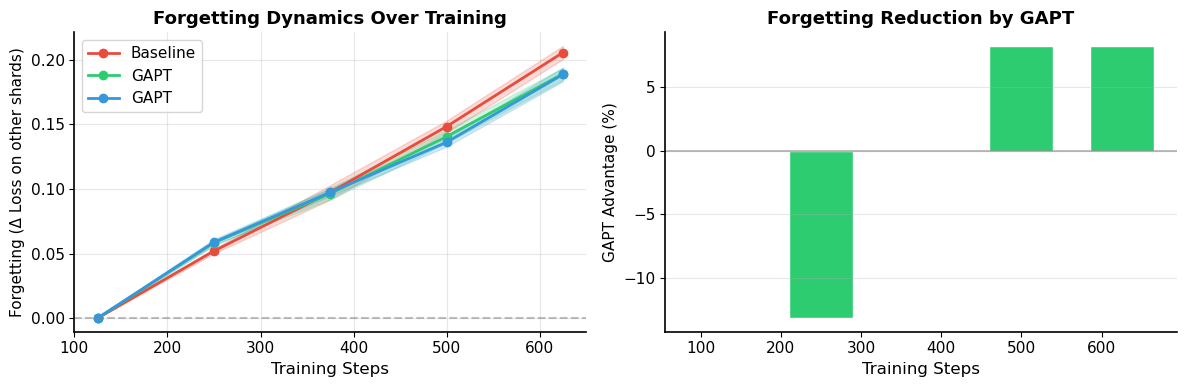


=== Forgetting by Step ===
  Step |   Baseline |       GAPT |  Reduction
---------------------------------------------
   125 |     0.0000 |     0.0000 |       0.0%
   250 |     0.0519 |     0.0588 |     -13.1%
   375 |     0.0974 |     0.0974 |      -0.0%
   500 |     0.1483 |     0.1361 |       8.2%
   625 |     0.2056 |     0.1886 |       8.2%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def compute_per_step_forgetting(results):
    """
    Compute forgetting at each validation step.
    
    Args:
        results: dict from parse_log_file with 'loss_trajectories' and 'train_shard'
    
    Returns:
        dict with 'steps', 'train_loss', 'other_loss', 'forgetting'
    """
    loss_traj = results['loss_trajectories']
    train_shard = results['train_shard']
    
    if not loss_traj or train_shard is None:
        return None
    
    # Get number of steps
    n_steps = len(list(loss_traj.values())[0])
    steps = [125 * (i + 1) for i in range(n_steps)]
    
    # Separate trained shard vs others
    train_key = f'bin{train_shard}'
    train_losses = np.array(loss_traj.get(train_key, []))
    
    other_losses = []
    for key, losses in loss_traj.items():
        if key != train_key:
            other_losses.append(losses)
    
    if not other_losses:
        return None
    
    other_losses = np.array(other_losses)  # (n_other_bins, n_steps)
    mean_other = other_losses.mean(axis=0)
    
    # Forgetting = increase in loss on other bins relative to step 0
    # (or use absolute loss if you prefer)
    forgetting = mean_other - mean_other[0]  # relative to start
    learning = train_losses[0] - train_losses  # decrease = learning
    
    return {
        'steps': steps,
        'train_loss': train_losses,
        'other_loss': mean_other,
        'forgetting': forgetting,
        'learning': learning,
    }


# ============================================
# Aggregate across all log files
# ============================================
from pathlib import Path

log_dir = Path("logs/forget-log")  # Fixed: hyphen not underscore
log_files = list(log_dir.glob("*.txt"))

# Group by method
method_dynamics = defaultdict(list)

for f in log_files:
    try:
        result = parse_log_file(str(f))
        info = parse_filename(f.name)
        
        if info['ckpt_source'] != 'base':  # Only from BASE ckpt
            continue
        
        dynamics = compute_per_step_forgetting(result)
        if dynamics:
            method_dynamics[info['method']].append(dynamics)
    except Exception as e:
        print(f"Error parsing {f.name}: {e}")

# ============================================
# Plot: Forgetting over training steps
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'baseline': '#E74C3C', 'gapt': '#2ECC71', 'gapt_softplus': '#3498DB'}
labels = {'baseline': 'Baseline', 'gapt': 'GAPT', 'gapt_softplus': 'GAPT'}

# LEFT: Forgetting trajectory
ax1 = axes[0]
for method, dynamics_list in method_dynamics.items():
    if method not in colors:
        continue
    
    # Average across shards
    all_forgetting = np.array([d['forgetting'] for d in dynamics_list])
    mean_forg = all_forgetting.mean(axis=0)
    std_forg = all_forgetting.std(axis=0)
    steps = dynamics_list[0]['steps']
    
    ax1.plot(steps, mean_forg, 'o-', color=colors[method], 
             label=labels[method], linewidth=2, markersize=6)
    ax1.fill_between(steps, mean_forg - std_forg, mean_forg + std_forg,
                     color=colors[method], alpha=0.2)

ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Training Steps', fontsize=12)
ax1.set_ylabel('Forgetting (Δ Loss on other shards)', fontsize=11)
ax1.set_title('Forgetting Dynamics Over Training', fontsize=13, fontweight='bold')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3)

# RIGHT: Gap between methods over time
ax2 = axes[1]
if 'baseline' in method_dynamics and 'gapt_softplus' in method_dynamics:
    baseline_forg = np.array([d['forgetting'] for d in method_dynamics['baseline']]).mean(axis=0)
    gapt_forg = np.array([d['forgetting'] for d in method_dynamics['gapt_softplus']]).mean(axis=0)
    steps = method_dynamics['baseline'][0]['steps']
    
    gap = baseline_forg - gapt_forg
    gap_pct = 100 * gap / (baseline_forg + 1e-6)
    
    ax2.bar(steps, gap_pct, width=80, color='#2ECC71', edgecolor='white')
    ax2.axhline(0, color='gray', linestyle='-', alpha=0.5)
    
    ax2.set_xlabel('Training Steps', fontsize=12)
    ax2.set_ylabel('GAPT Advantage (%)', fontsize=11)
    ax2.set_title('Forgetting Reduction by GAPT', fontsize=13, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('forgetting_dynamics.png', dpi=200, facecolor='white')
plt.show()

# Print table
# Print table
steps = [125]
print("\n=== Forgetting by Step ===")
if 'baseline' in method_dynamics and 'gapt_softplus' in method_dynamics:
    baseline_forg = np.array([d['forgetting'] for d in method_dynamics['baseline']]).mean(axis=0)
    gapt_forg = np.array([d['forgetting'] for d in method_dynamics['gapt_softplus']]).mean(axis=0)
    steps = method_dynamics['baseline'][0]['steps']
    
    print(f"{'Step':>6} | {'Baseline':>10} | {'GAPT':>10} | {'Reduction':>10}")
    print("-" * 45)
    for i, step in enumerate(steps):
        b = baseline_forg[i]
        g = gapt_forg[i]
        red = 100 * (b - g) / (b + 1e-6) if b > 0 else 0
        print(f"{step:>6} | {b:>10.4f} | {g:>10.4f} | {red:>9.1f}%")
else:
    print("Missing data for baseline or gapt_softplus")
    print(f"Available methods: {list(method_dynamics.keys())}")

In [16]:
from pathlib import Path
from collections import defaultdict

log_dir = Path("logs/forget-log")  # Fixed: hyphen not underscore
log_files = list(log_dir.glob("*.txt"))

print(f"Found {len(log_files)} log files in {log_dir}")
for f in log_files[:5]:  # Show first 5
    print(f"  - {f.name}")

# Group by method
method_dynamics = defaultdict(list)

for f in log_files:
    try:
        result = parse_log_file(str(f))
        info = parse_filename(f.name)
        
        print(f"\n--- {f.name} ---")
        print(f"  method: {info['method']}, ckpt_source: {info['ckpt_source']}, shard: {info['shard']}")
        print(f"  train_shard: {result['train_shard']}")
        print(f"  loss_trajectories keys: {list(result['loss_trajectories'].keys())}")
        
        if info['ckpt_source'] != 'base':
            print("  SKIPPED (not from base)")
            continue
        
        dynamics = compute_per_step_forgetting(result)
        if dynamics:
            print(f"  ✓ Got dynamics with {len(dynamics['steps'])} steps")
            method_dynamics[info['method']].append(dynamics)
        else:
            print("  ✗ No dynamics computed")
            
    except Exception as e:
        print(f"Error parsing {f.name}: {e}")

print(f"\n=== Summary ===")
print(f"Methods found: {list(method_dynamics.keys())}")
for method, dlist in method_dynamics.items():
    print(f"  {method}: {len(dlist)} runs")

Found 60 log files in logs/forget-log
  - small_gapt_from_gapt_shard8_20260112_020936.txt
  - small_gapt_softplus_from_gapt_shard2_20260111_203124.txt
  - small_baseline_from_base_shard4_20260111_115339.txt
  - small_gapt_from_base_shard8_20260111_161237.txt
  - small_baseline_from_gapt_shard8_20260112_014936.txt

--- small_gapt_from_gapt_shard8_20260112_020936.txt ---
  method: gapt, ckpt_source: gapt, shard: 8
  train_shard: 8
  loss_trajectories keys: ['bin0', 'bin1', 'bin8', 'bin7', 'bin6', 'bin5', 'bin3', 'bin2', 'bin9', 'bin4']
  SKIPPED (not from base)

--- small_gapt_softplus_from_gapt_shard2_20260111_203124.txt ---
  method: gapt_softplus, ckpt_source: gapt, shard: 2
  train_shard: 2
  loss_trajectories keys: ['bin0', 'bin1', 'bin8', 'bin7', 'bin6', 'bin5', 'bin3', 'bin2', 'bin9', 'bin4']
  SKIPPED (not from base)

--- small_baseline_from_base_shard4_20260111_115339.txt ---
  method: baseline, ckpt_source: base, shard: 4
  train_shard: 4
  loss_trajectories keys: ['bin0', 'bin

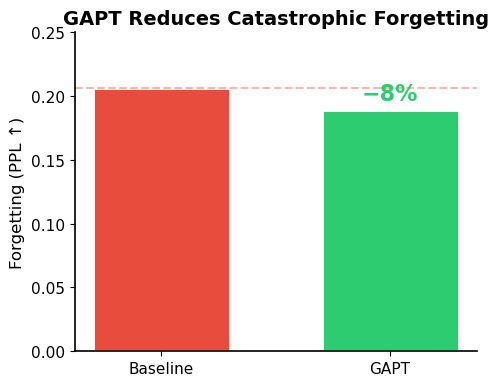

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

methods = ['Baseline', 'GAPT']
forgetting = [0.206, 0.189]
colors = ['#E74C3C', '#2ECC71']  # Red vs Green - high contrast

bars = ax.bar(methods, forgetting, color=colors, edgecolor='white', linewidth=2, width=0.6)

# Baseline reference line
ax.axhline(0.206, color='#E74C3C', linestyle='--', alpha=0.4, linewidth=1.5)

# Highlight reduction
ax.annotate('−8%', xy=(1, 0.197), fontsize=16, fontweight='bold', 
            color='#2ECC71', ha='center')

ax.set_ylabel('Forgetting (PPL ↑)', fontsize=12)
ax.set_title('GAPT Reduces Catastrophic Forgetting', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forgetting_simple.png', dpi=200, facecolor='white')
plt.show()

In [ ]:
# More on catastrophic forgetting: 
# Q1. Why does GAPT ckpt + GAPT finetune forgets more, whilst ckpt + GAPT finetune forgets less?
#     What does MBE implies practically? (Current experiment running to probe on this)
# Q2. Does the benefit grows when training step is increased? 
# Q3. DOes the benefit componds with EAFT? 

In [50]:
from src.anal_grad import analyze_gradient_quadrants

# Full analysis with one call
analyze_gradient_quadrants("logs/log_run3", output_dir=".")

# Or step by step
from src.anal_grad import load_token_stats, create_quadrant_animation

all_stats = load_token_stats("logs/log_run3")
create_quadrant_animation(all_stats, "my_animation.gif", duration_ms=500)

Loading token stats from logs/log_run3...
Loaded 15 steps
=== Quadrant Gradient Summary ===

Step 0:
  uncertain_wrong     : grad=0.0000, n=163840, 100.0%

Step 875:
  confident_correct   : grad=0.7794, n=35917, 21.9%
  confident_wrong     : grad=0.9031, n=46003, 28.1%
  uncertain_wrong     : grad=1.3121, n=81920, 50.0%

Step 1750:
  confident_correct   : grad=0.6248, n=41387, 25.3%
  confident_wrong     : grad=0.6778, n=40533, 24.7%
  uncertain_wrong     : grad=1.0472, n=81920, 50.0%
Saved: quadrant_gradient_dynamics.png
Generating quadrant animation frames...
  Frame 15/15 (step 1750)
Saving GIF...
Saved: quadrant_dynamics.gif
Generating quadrant animation frames...
  Frame 15/15 (step 1750)
Saving GIF...
Saved: my_animation.gif


In [22]:
from src.anal_grad import load_patch_stats, analyze_patch_mbe_dynamics

# Load the new patch-level stats
patch_stats = load_patch_stats("logs/log_run2")

# Analyze with 4096x more data
df = analyze_patch_mbe_dynamics("logs/log_run2", save_path="patch_mbe_dynamics.png")

=== Patch-Level MBE Correlations ===
  Step |  N Patches |   MBE-Loss |   MBE-Prob
---------------------------------------------
   0.0 |    81920.0 |        nan |        nan
 125.0 |    81920.0 |     -0.108 |      0.118
 250.0 |    81920.0 |     -0.115 |      0.139
 375.0 |    81920.0 |     -0.096 |      0.106
 500.0 |    81920.0 |     -0.112 |      0.119
 625.0 |    81920.0 |     -0.118 |      0.139
 750.0 |    81920.0 |     -0.113 |      0.131
 875.0 |    81920.0 |     -0.121 |      0.145
1000.0 |    81920.0 |     -0.121 |      0.144
1125.0 |    81920.0 |     -0.116 |      0.140
1250.0 |    81920.0 |     -0.122 |      0.157
1375.0 |    81920.0 |     -0.128 |      0.165
1500.0 |    81920.0 |     -0.132 |      0.174
1625.0 |    81920.0 |     -0.137 |      0.181
1750.0 |    81920.0 |     -0.145 |      0.192

Saved: patch_mbe_dynamics.png


/Users/ksgk/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ksgk/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [30]:
df

,step,n_patches,mbe_loss_corr,mbe_prob_corr,mbe_entropy_corr,mean_mbe,mean_loss
0,0,81920,NaN,NaN,NaN,2.029626,10.825837
1,125,81920,-0.107793,0.118082,-0.169153,1.201890,4.276452
2,250,81920,-0.114679,0.138535,-0.179305,0.954167,3.874013
3,375,81920,-0.096435,0.105943,-0.158739,0.769225,3.696143
4,500,81920,-0.112217,0.119343,-0.180736,0.646573,3.582373
5,625,81920,-0.117762,0.139328,-0.196172,0.575828,3.508699
6,750,81920,-0.113406,0.130984,-0.181046,0.531175,3.452706
7,875,81920,-0.121286,0.145330,-0.191400,0.491747,3.409583
8,1000,81920,-0.120758,0.143800,-0.193167,0.469752,3.378217
9,1125,81920,-0.115972,0.140352,-0.190244,0.446429,3.345745


=== Step 125: MBE vs Entropy ===
Correlation MBE-Entropy: -0.169


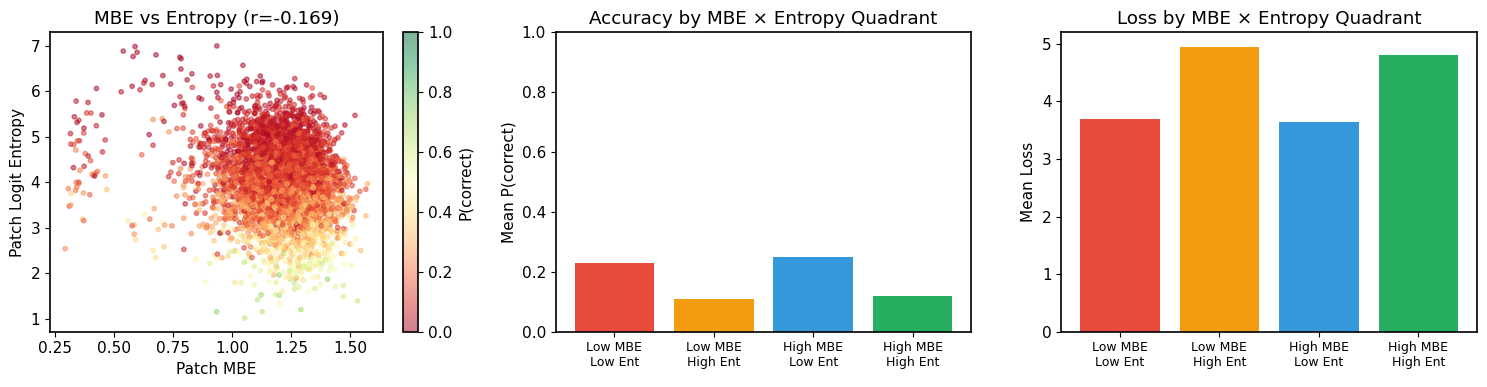


Quadrant                  |    Count |     Prob |     Loss
-------------------------------------------------------
Low MBE, Low Ent          |    18839 |    0.231 |    3.690
Low MBE, High Ent         |    22121 |    0.108 |    4.951
High MBE, Low Ent         |    22121 |    0.250 |    3.649
High MBE, High Ent        |    18839 |    0.118 |    4.807
=== Step 500: MBE vs Entropy ===
Correlation MBE-Entropy: -0.181


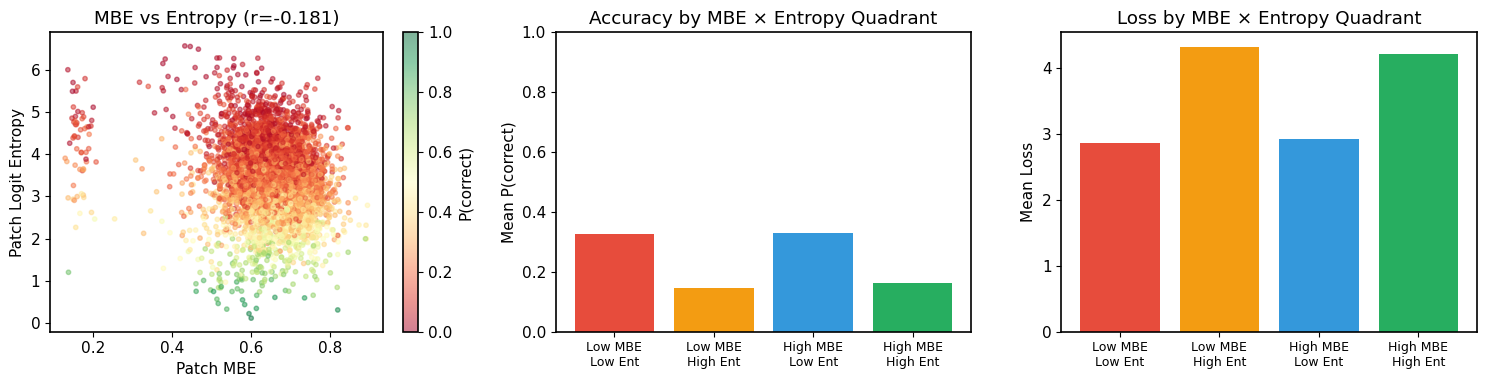


Quadrant                  |    Count |     Prob |     Loss
-------------------------------------------------------
Low MBE, Low Ent          |    17912 |    0.328 |    2.861
Low MBE, High Ent         |    23048 |    0.147 |    4.323
High MBE, Low Ent         |    23048 |    0.331 |    2.919
High MBE, High Ent        |    17912 |    0.163 |    4.205
=== Step 1000: MBE vs Entropy ===
Correlation MBE-Entropy: -0.193


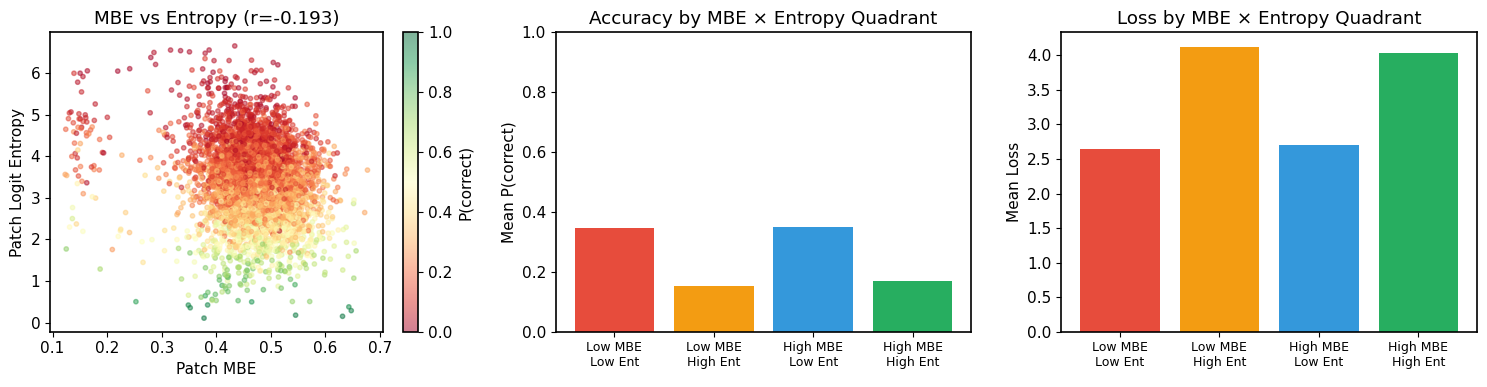


Quadrant                  |    Count |     Prob |     Loss
-------------------------------------------------------
Low MBE, Low Ent          |    17667 |    0.346 |    2.638
Low MBE, High Ent         |    23293 |    0.153 |    4.127
High MBE, Low Ent         |    23293 |    0.351 |    2.697
High MBE, High Ent        |    17667 |    0.171 |    4.030
=== Step 1750: MBE vs Entropy ===
Correlation MBE-Entropy: -0.225


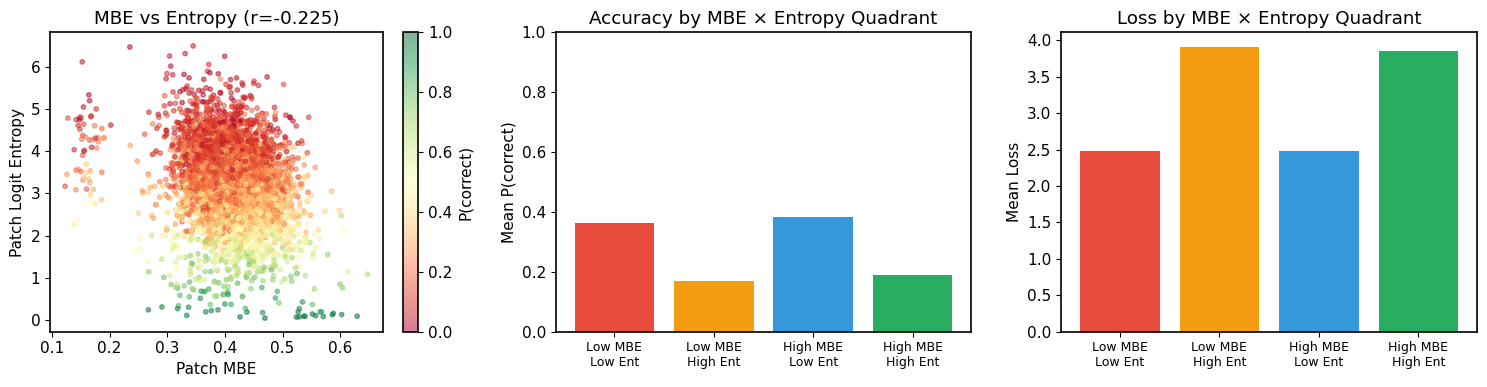


Quadrant                  |    Count |     Prob |     Loss
-------------------------------------------------------
Low MBE, Low Ent          |    17191 |    0.363 |    2.483
Low MBE, High Ent         |    23769 |    0.168 |    3.913
High MBE, Low Ent         |    23769 |    0.383 |    2.476
High MBE, High Ent        |    17191 |    0.189 |    3.846


In [33]:
# ============================================
# (b) MBE vs Logit Entropy relationship
# ============================================

def analyze_mbe_vs_entropy(log_dir, step=500):
    """Analyze relationship between patch MBE and logit entropy."""
    f = Path(log_dir) / f"patch_stats_step{step:06d}.pt"
    stats = torch.load(f)
    
    patch_mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
    patch_entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
    patch_prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
    patch_loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
    
    # Correlation
    corr_mbe_entropy = np.corrcoef(patch_mbe, patch_entropy)[0, 1]
    
    print(f"=== Step {step}: MBE vs Entropy ===")
    print(f"Correlation MBE-Entropy: {corr_mbe_entropy:.3f}")
    
    # Scatter plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Sample for visibility
    n = min(5000, len(patch_mbe))
    idx = np.random.choice(len(patch_mbe), n, replace=False)
    
    # (1) MBE vs Entropy, colored by prob
    ax1 = axes[0]
    sc = ax1.scatter(patch_mbe[idx], patch_entropy[idx], c=patch_prob[idx], 
                     cmap='RdYlGn', alpha=0.5, s=10, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax1, label='P(correct)')
    ax1.set_xlabel('Patch MBE')
    ax1.set_ylabel('Patch Logit Entropy')
    ax1.set_title(f'MBE vs Entropy (r={corr_mbe_entropy:.3f})')
    
    # (2) Quadrants: MBE x Entropy → Accuracy
    ax2 = axes[1]
    mbe_med = np.median(patch_mbe)
    ent_med = np.median(patch_entropy)
    
    quadrants = {
        'Low MBE, Low Ent': (patch_mbe < mbe_med) & (patch_entropy < ent_med),
        'Low MBE, High Ent': (patch_mbe < mbe_med) & (patch_entropy >= ent_med),
        'High MBE, Low Ent': (patch_mbe >= mbe_med) & (patch_entropy < ent_med),
        'High MBE, High Ent': (patch_mbe >= mbe_med) & (patch_entropy >= ent_med),
    }
    
    names = list(quadrants.keys())
    probs = [patch_prob[mask].mean() for mask in quadrants.values()]
    colors = ['#E74C3C', '#F39C12', '#3498DB', '#27AE60']
    
    ax2.bar(range(4), probs, color=colors)
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(['Low MBE\nLow Ent', 'Low MBE\nHigh Ent', 
                         'High MBE\nLow Ent', 'High MBE\nHigh Ent'], fontsize=9)
    ax2.set_ylabel('Mean P(correct)')
    ax2.set_title('Accuracy by MBE × Entropy Quadrant')
    ax2.set_ylim(0, 1)
    
    # (3) Same for loss
    ax3 = axes[2]
    losses = [patch_loss[mask].mean() for mask in quadrants.values()]
    ax3.bar(range(4), losses, color=colors)
    ax3.set_xticks(range(4))
    ax3.set_xticklabels(['Low MBE\nLow Ent', 'Low MBE\nHigh Ent', 
                         'High MBE\nLow Ent', 'High MBE\nHigh Ent'], fontsize=9)
    ax3.set_ylabel('Mean Loss')
    ax3.set_title('Loss by MBE × Entropy Quadrant')
    
    plt.tight_layout()
    plt.savefig(f'mbe_entropy_analysis_step{step}.png', dpi=150)
    plt.show()
    
    # Print quadrant stats
    print(f"\n{'Quadrant':<25} | {'Count':>8} | {'Prob':>8} | {'Loss':>8}")
    print("-" * 55)
    for name, mask in quadrants.items():
        print(f"{name:<25} | {mask.sum():>8} | {patch_prob[mask].mean():>8.3f} | {patch_loss[mask].mean():>8.3f}")

# Run for multiple steps
for step in [125, 500, 1000, 1750]:
    try:
        analyze_mbe_vs_entropy("logs/log_run2", step)
    except:
        pass

=== MBE-Prob Correlation Analysis ===
Data Subset               |          N |  Correlation
-------------------------------------------------------
All data                  |  1,228,800 |      -0.3772
Healthy (MBE ≥ 0.2)       |  1,217,342 |      -0.3835
Collapsed (MBE < 0.2)     |     11,458 |      -0.1024

=== MBE-Loss Correlation ===
All data                  |       0.7371
Healthy (MBE ≥ 0.2)       |       0.7443


/Users/ksgk/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ksgk/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


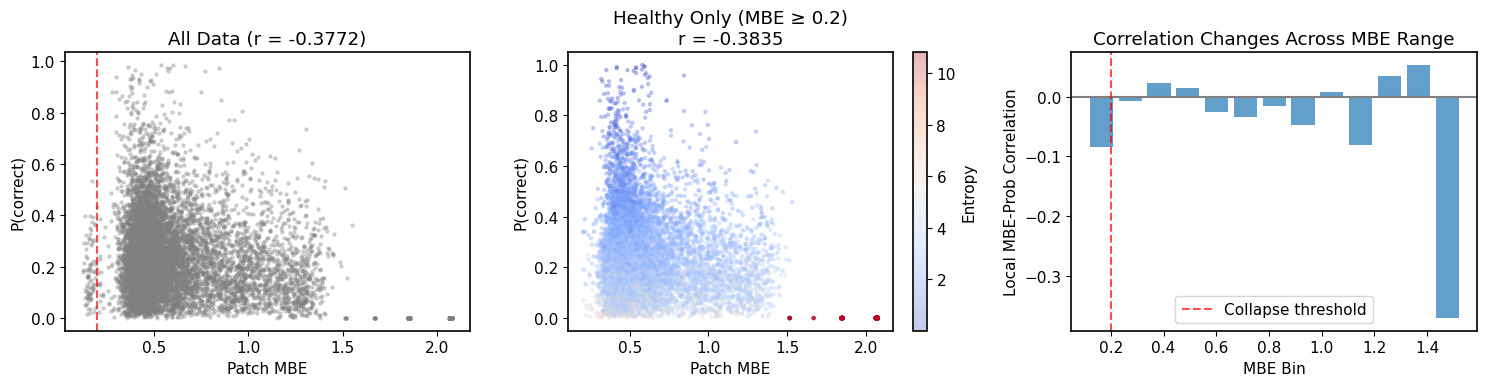


=== KEY INSIGHT ===
Excluding collapsed points WEAKENS the correlation:
  All: -0.3772 → Healthy: -0.3835
  The collapsed points were driving the positive correlation!


In [39]:
import numpy as np

# Assuming 'data' dict is already loaded from previous code

# ============================================
# Compare correlations: All data vs Non-collapsed
# ============================================

# All data
corr_all = np.corrcoef(data['mbe'], data['prob'])[0, 1]

# Exclude collapsed (MBE < 0.2)
healthy_mask = data['mbe'] >= 0.2
corr_healthy = np.corrcoef(data['mbe'][healthy_mask], data['prob'][healthy_mask])[0, 1]

# Only collapsed
collapsed_mask = data['mbe'] < 0.2
corr_collapsed = np.corrcoef(data['mbe'][collapsed_mask], data['prob'][collapsed_mask])[0, 1]

print("=== MBE-Prob Correlation Analysis ===")
print(f"{'Data Subset':<25} | {'N':>10} | {'Correlation':>12}")
print("-" * 55)
print(f"{'All data':<25} | {len(data['mbe']):>10,} | {corr_all:>12.4f}")
print(f"{'Healthy (MBE ≥ 0.2)':<25} | {healthy_mask.sum():>10,} | {corr_healthy:>12.4f}")
print(f"{'Collapsed (MBE < 0.2)':<25} | {collapsed_mask.sum():>10,} | {corr_collapsed:>12.4f}")

# Also check MBE-Loss correlation
corr_loss_all = np.corrcoef(data['mbe'], data['loss'])[0, 1]
corr_loss_healthy = np.corrcoef(data['mbe'][healthy_mask], data['loss'][healthy_mask])[0, 1]

print(f"\n=== MBE-Loss Correlation ===")
print(f"{'All data':<25} | {corr_loss_all:>12.4f}")
print(f"{'Healthy (MBE ≥ 0.2)':<25} | {corr_loss_healthy:>12.4f}")

# ============================================
# Visualize the difference
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

n_sample = 10000

# (1) All data
ax1 = axes[0]
idx = np.random.choice(len(data['mbe']), min(n_sample, len(data['mbe'])), replace=False)
ax1.scatter(data['mbe'][idx], data['prob'][idx], alpha=0.3, s=5, c='gray')
ax1.set_xlabel('Patch MBE')
ax1.set_ylabel('P(correct)')
ax1.set_title(f'All Data (r = {corr_all:.4f})')
ax1.axvline(0.2, color='red', linestyle='--', alpha=0.7)

# (2) Healthy only
ax2 = axes[1]
healthy_idx = np.where(healthy_mask)[0]
sample_healthy = np.random.choice(healthy_idx, min(n_sample, len(healthy_idx)), replace=False)
sc = ax2.scatter(data['mbe'][sample_healthy], data['prob'][sample_healthy], 
                  c=data['entropy'][sample_healthy], cmap='coolwarm', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax2, label='Entropy')
ax2.set_xlabel('Patch MBE')
ax2.set_ylabel('P(correct)')
ax2.set_title(f'Healthy Only (MBE ≥ 0.2)\nr = {corr_healthy:.4f}')

# (3) Correlation by MBE bin
ax3 = axes[2]
mbe_bins = np.linspace(0, data['mbe'].max(), 20)
bin_corrs = []
bin_centers = []
for i in range(len(mbe_bins) - 1):
    mask = (data['mbe'] >= mbe_bins[i]) & (data['mbe'] < mbe_bins[i+1])
    if mask.sum() > 100:
        bin_corrs.append(np.corrcoef(data['mbe'][mask], data['prob'][mask])[0, 1])
        bin_centers.append((mbe_bins[i] + mbe_bins[i+1]) / 2)

ax3.bar(bin_centers, bin_corrs, width=(mbe_bins[1] - mbe_bins[0]) * 0.8, alpha=0.7)
ax3.axhline(0, color='gray', linestyle='-')
ax3.axvline(0.2, color='red', linestyle='--', alpha=0.7, label='Collapse threshold')
ax3.set_xlabel('MBE Bin')
ax3.set_ylabel('Local MBE-Prob Correlation')
ax3.set_title('Correlation Changes Across MBE Range')
ax3.legend()

plt.tight_layout()
plt.savefig('mbe_correlation_analysis.png', dpi=150)
plt.show()

# ============================================
# Key insight
# ============================================
print(f"\n=== KEY INSIGHT ===")
if corr_healthy < corr_all:
    print(f"Excluding collapsed points WEAKENS the correlation:")
    print(f"  All: {corr_all:.4f} → Healthy: {corr_healthy:.4f}")
    print(f"  The collapsed points were driving the positive correlation!")
else:
    print(f"Excluding collapsed points STRENGTHENS/CHANGES the correlation:")
    print(f"  All: {corr_all:.4f} → Healthy: {corr_healthy:.4f}")
    print(f"  The healthy data shows a different relationship!")

=== Optimal MBE Per Step ===
  Step |  Optimal MBE | Max P(correct) |   Mean MBE |            MBE Range
---------------------------------------------------------------------------
     0 |       1.5067 |         0.0000 |     2.0296 |         [0.90, 2.08]
   125 |       1.5259 |         0.2794 |     1.2019 |         [0.25, 1.59]
   250 |       1.2555 |         0.3183 |     0.9542 |         [0.15, 1.36]
   375 |       1.0338 |         0.3136 |     0.7698 |         [0.15, 1.08]
   500 |       0.8593 |         0.3424 |     0.6480 |         [0.15, 0.95]
   625 |       0.7677 |         0.3694 |     0.5773 |         [0.15, 0.85]
   750 |       0.7175 |         0.3725 |     0.5334 |         [0.15, 0.79]
   875 |       0.6752 |         0.4471 |     0.4929 |         [0.15, 0.77]
  1000 |       0.6423 |         0.4557 |     0.4713 |         [0.15, 0.73]
  1125 |       0.6275 |         0.5038 |     0.4477 |         [0.15, 0.69]
  1250 |       0.6058 |         0.5957 |     0.4342 |         [0.15, 0

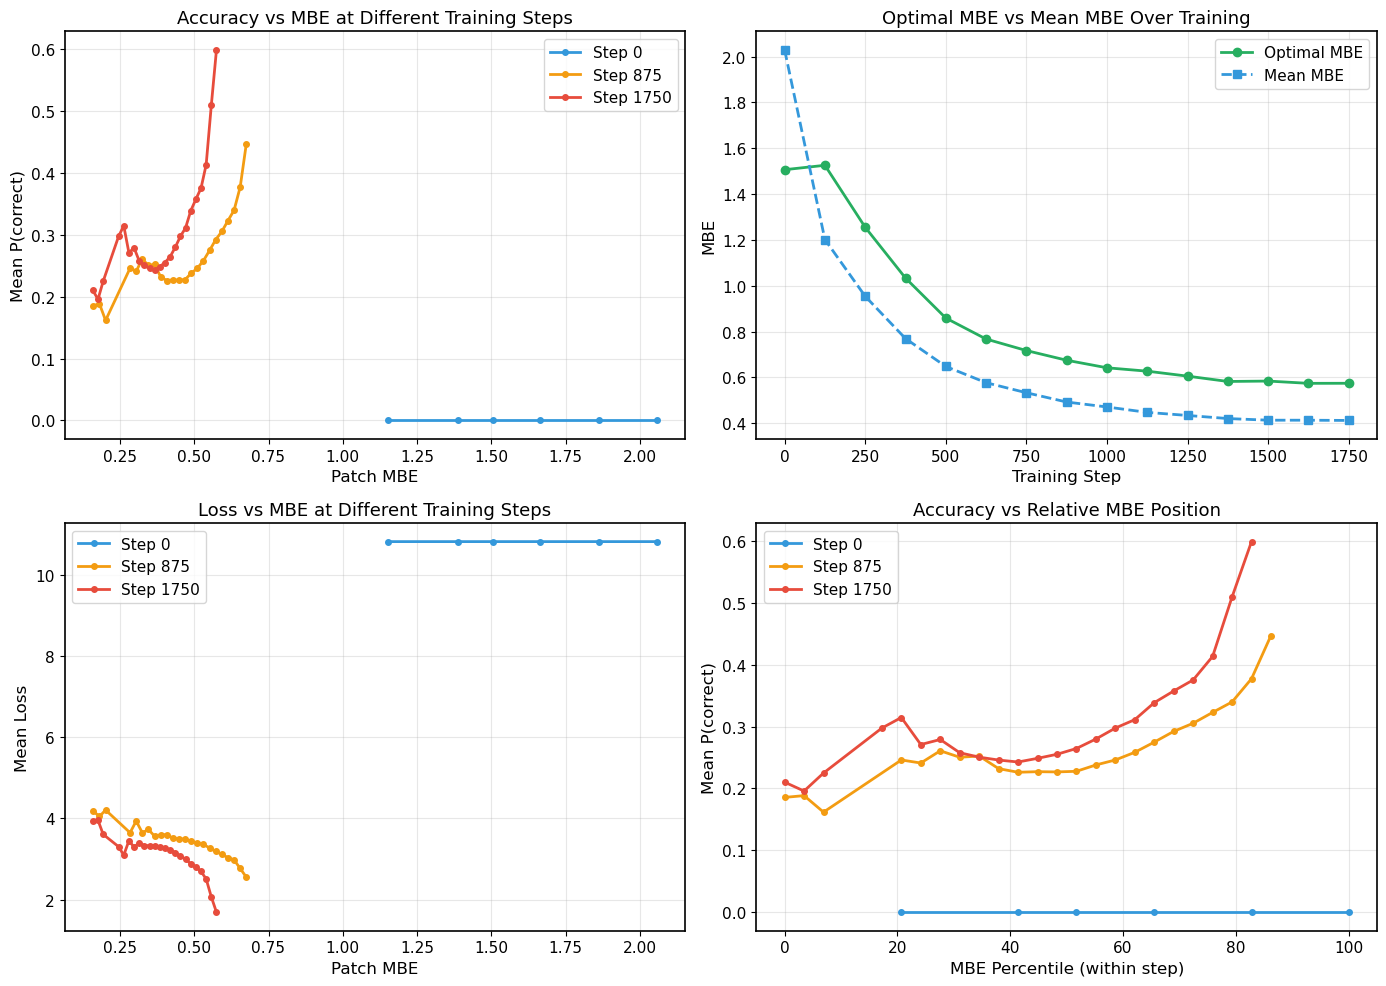


=== Is Optimal MBE at a Consistent Percentile? ===
Optimal MBE percentile: mean=85.4%, std=9.8%
Range: [51.7%, 95.0%]

✓ CONSISTENT: Optimal is always around 85th percentile of MBE distribution


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from scipy.optimize import minimize_scalar
from scipy.interpolate import UnivariateSpline

def find_optimal_mbe_per_step(log_dir, n_bins=30):
    """Find the MBE value that maximizes P(correct) at each step."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    results = []
    all_curves = {}
    
    for f in patch_files:
        step = int(f.stem.split('step')[1])
        stats = torch.load(f)
        
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
        
        # Exclude collapsed
        healthy = mbe >= 0.15
        mbe_h, prob_h, loss_h = mbe[healthy], prob[healthy], loss[healthy]
        
        # Bin MBE and compute mean accuracy per bin
        mbe_min, mbe_max = mbe_h.min(), mbe_h.max()
        bins = np.linspace(mbe_min, mbe_max, n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        bin_probs = []
        bin_losses = []
        bin_counts = []
        
        for i in range(n_bins):
            mask = (mbe_h >= bins[i]) & (mbe_h < bins[i+1])
            if mask.sum() > 50:
                bin_probs.append(prob_h[mask].mean())
                bin_losses.append(loss_h[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_probs.append(np.nan)
                bin_losses.append(np.nan)
                bin_counts.append(0)
        
        bin_probs = np.array(bin_probs)
        bin_losses = np.array(bin_losses)
        
        # Find optimal MBE (max accuracy)
        valid = ~np.isnan(bin_probs)
        if valid.sum() > 5:
            optimal_idx = np.nanargmax(bin_probs)
            optimal_mbe = bin_centers[optimal_idx]
            optimal_prob = bin_probs[optimal_idx]
            
            # Also find min loss MBE
            min_loss_idx = np.nanargmin(bin_losses)
            min_loss_mbe = bin_centers[min_loss_idx]
        else:
            optimal_mbe = optimal_prob = min_loss_mbe = np.nan
        
        results.append({
            'step': step,
            'optimal_mbe_prob': optimal_mbe,
            'optimal_prob': optimal_prob,
            'min_loss_mbe': min_loss_mbe,
            'mean_mbe': mbe_h.mean(),
            'mbe_range': (mbe_min, mbe_max),
        })
        
        all_curves[step] = {
            'bin_centers': bin_centers,
            'bin_probs': bin_probs,
            'bin_losses': bin_losses,
        }
    
    return results, all_curves

results, curves = find_optimal_mbe_per_step("logs/log_run2")

# ============================================
# Print summary
# ============================================
print("=== Optimal MBE Per Step ===")
print(f"{'Step':>6} | {'Optimal MBE':>12} | {'Max P(correct)':>14} | {'Mean MBE':>10} | {'MBE Range':>20}")
print("-" * 75)
for r in results:
    rng = f"[{r['mbe_range'][0]:.2f}, {r['mbe_range'][1]:.2f}]"
    print(f"{r['step']:>6} | {r['optimal_mbe_prob']:>12.4f} | {r['optimal_prob']:>14.4f} | {r['mean_mbe']:>10.4f} | {rng:>20}")

# ============================================
# Visualize
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Accuracy vs MBE curves at different steps
ax1 = axes[0, 0]
steps_to_plot = [results[0]['step'], results[len(results)//2]['step'], results[-1]['step']]
colors = ['#3498DB', '#F39C12', '#E74C3C']

for step, color in zip(steps_to_plot, colors):
    curve = curves[step]
    valid = ~np.isnan(curve['bin_probs'])
    ax1.plot(curve['bin_centers'][valid], curve['bin_probs'][valid], 'o-', 
             color=color, label=f'Step {step}', linewidth=2, markersize=4)

ax1.set_xlabel('Patch MBE', fontsize=12)
ax1.set_ylabel('Mean P(correct)', fontsize=12)
ax1.set_title('Accuracy vs MBE at Different Training Steps', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

# (2) Optimal MBE over training
ax2 = axes[0, 1]
steps = [r['step'] for r in results]
optimal_mbes = [r['optimal_mbe_prob'] for r in results]
mean_mbes = [r['mean_mbe'] for r in results]

ax2.plot(steps, optimal_mbes, 'o-', color='#27AE60', linewidth=2, label='Optimal MBE')
ax2.plot(steps, mean_mbes, 's--', color='#3498DB', linewidth=2, label='Mean MBE')
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('MBE', fontsize=12)
ax2.set_title('Optimal MBE vs Mean MBE Over Training', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

# (3) Loss vs MBE curves
ax3 = axes[1, 0]
for step, color in zip(steps_to_plot, colors):
    curve = curves[step]
    valid = ~np.isnan(curve['bin_losses'])
    ax3.plot(curve['bin_centers'][valid], curve['bin_losses'][valid], 'o-', 
             color=color, label=f'Step {step}', linewidth=2, markersize=4)

ax3.set_xlabel('Patch MBE', fontsize=12)
ax3.set_ylabel('Mean Loss', fontsize=12)
ax3.set_title('Loss vs MBE at Different Training Steps', fontsize=13)
ax3.legend()
ax3.grid(alpha=0.3)

# (4) Is there a universal optimal relative position?
ax4 = axes[1, 1]
# Normalize MBE to percentile within each step
for step, color in zip(steps_to_plot, colors):
    curve = curves[step]
    valid = ~np.isnan(curve['bin_probs'])
    # Convert to percentile (0-100)
    x_norm = 100 * (curve['bin_centers'] - curve['bin_centers'].min()) / (curve['bin_centers'].max() - curve['bin_centers'].min())
    ax4.plot(x_norm[valid], curve['bin_probs'][valid], 'o-', 
             color=color, label=f'Step {step}', linewidth=2, markersize=4)

ax4.set_xlabel('MBE Percentile (within step)', fontsize=12)
ax4.set_ylabel('Mean P(correct)', fontsize=12)
ax4.set_title('Accuracy vs Relative MBE Position', fontsize=13)
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_mbe_analysis.png', dpi=150)
plt.show()

# ============================================
# Statistical test: Is optimal always around same percentile?
# ============================================
print("\n=== Is Optimal MBE at a Consistent Percentile? ===")
optimal_percentiles = []
for r in results:
    mbe_range = r['mbe_range']
    opt = r['optimal_mbe_prob']
    if not np.isnan(opt):
        pct = 100 * (opt - mbe_range[0]) / (mbe_range[1] - mbe_range[0])
        optimal_percentiles.append(pct)
        
print(f"Optimal MBE percentile: mean={np.mean(optimal_percentiles):.1f}%, std={np.std(optimal_percentiles):.1f}%")
print(f"Range: [{np.min(optimal_percentiles):.1f}%, {np.max(optimal_percentiles):.1f}%]")

if np.std(optimal_percentiles) < 15:
    print(f"\n✓ CONSISTENT: Optimal is always around {np.mean(optimal_percentiles):.0f}th percentile of MBE distribution")
else:
    print(f"\n✗ VARIABLE: Optimal percentile varies significantly across steps")

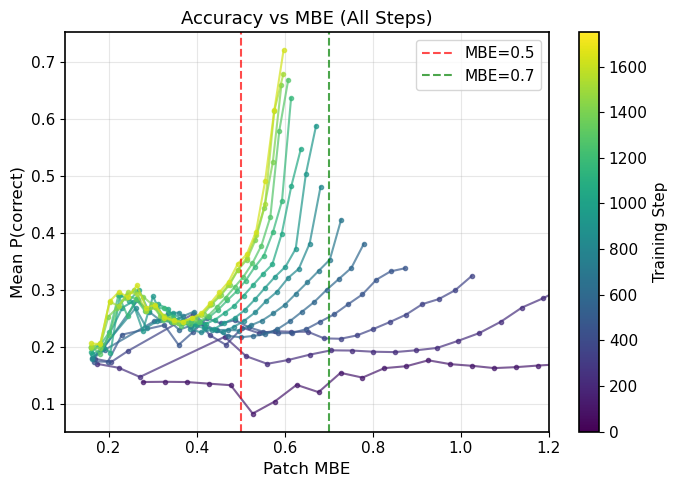


=== Optimal MBE Statistics ===
Mean:   0.7973
Median: 0.6763
Std:    0.2679
Range:  [0.5925, 1.4751]


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

def plot_all_steps_accuracy_vs_mbe(log_dir, n_bins=25):
    """Plot accuracy vs MBE for ALL steps on one figure."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
    
    # Color map for steps
    cmap = plt.cm.viridis
    n_steps = len(patch_files)
    
    all_optimal_mbe = []
    all_steps = []
    
    for i, f in enumerate(patch_files):
        step = int(f.stem.split('step')[1])
        stats = torch.load(f)
        
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        
        # Exclude collapsed
        healthy = mbe >= 0.15
        mbe_h, prob_h = mbe[healthy], prob[healthy]
        
        if len(mbe_h) < 100:
            continue
        
        # Bin MBE
        mbe_min, mbe_max = mbe_h.min(), min(mbe_h.max(), 1.5)  # Cap at 1.5 for visibility
        bins = np.linspace(mbe_min, mbe_max, n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        bin_probs = []
        for j in range(n_bins):
            mask = (mbe_h >= bins[j]) & (mbe_h < bins[j+1])
            if mask.sum() > 30:
                bin_probs.append(prob_h[mask].mean())
            else:
                bin_probs.append(np.nan)
        
        bin_probs = np.array(bin_probs)
        valid = ~np.isnan(bin_probs)
        
        if valid.sum() > 3:
            color = cmap(i / n_steps)
            ax1.plot(bin_centers[valid], bin_probs[valid], 'o-', 
                     color=color, linewidth=1.5, markersize=3, alpha=0.7)
            
            # Find optimal
            optimal_idx = np.nanargmax(bin_probs)
            optimal_mbe = bin_centers[optimal_idx]
            all_optimal_mbe.append(optimal_mbe)
            all_steps.append(step)
    
    ax1.set_xlabel('Patch MBE', fontsize=12)
    ax1.set_ylabel('Mean P(correct)', fontsize=12)
    ax1.set_title('Accuracy vs MBE (All Steps)', fontsize=13)
    ax1.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='MBE=0.5')
    ax1.axvline(0.7, color='green', linestyle='--', alpha=0.7, label='MBE=0.7')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0.1, 1.2)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max(all_steps)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1)
    cbar.set_label('Training Step')
    
    plt.tight_layout()
    plt.savefig('all_steps_optimal_mbe.png', dpi=150)
    plt.show()
    
    # Summary stats
    print(f"\n=== Optimal MBE Statistics ===")
    print(f"Mean:   {np.mean(all_optimal_mbe):.4f}")
    print(f"Median: {np.median(all_optimal_mbe):.4f}")
    print(f"Std:    {np.std(all_optimal_mbe):.4f}")
    print(f"Range:  [{np.min(all_optimal_mbe):.4f}, {np.max(all_optimal_mbe):.4f}]")
    
    return all_optimal_mbe, all_steps

optimal_mbes, steps = plot_all_steps_accuracy_vs_mbe("logs/log_run2")

=== Per-Step Correlations (Excluding Collapsed, MBE < 0.2) ===
  Step |  N Healthy | % Collapsed |   MBE-Prob |   MBE-Loss
-----------------------------------------------------------------
     0 |     81,920 |       0.00% |        nan |        nan
   125 |     81,920 |       0.00% |     0.1181 |    -0.1078
   250 |     81,536 |       0.47% |     0.1427 |    -0.1123
   375 |     81,244 |       0.83% |     0.1045 |    -0.0846
   500 |     81,045 |       1.07% |     0.1171 |    -0.0975
   625 |     81,015 |       1.10% |     0.1444 |    -0.1059
   750 |     80,975 |       1.15% |     0.1306 |    -0.0956
   875 |     80,985 |       1.14% |     0.1481 |    -0.1064
  1000 |     80,968 |       1.16% |     0.1451 |    -0.1037
  1125 |     80,966 |       1.16% |     0.1405 |    -0.0987
  1250 |     80,961 |       1.17% |     0.1609 |    -0.1067
  1375 |     80,957 |       1.18% |     0.1685 |    -0.1129
  1500 |     80,948 |       1.19% |     0.1783 |    -0.1174
  1625 |     80,952 |       1.1

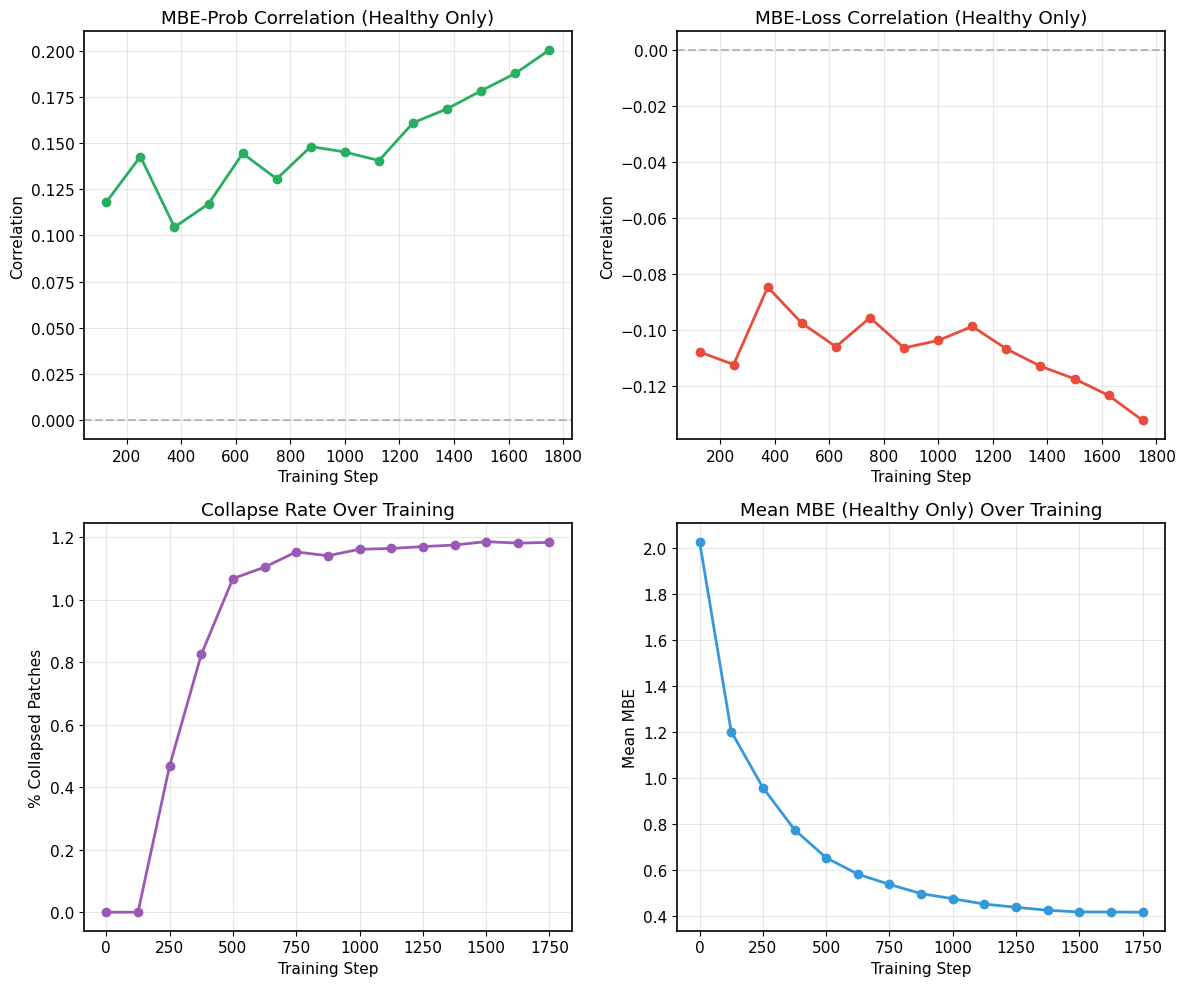


=== SUMMARY ===
MBE-Prob correlation (healthy): mean=0.1491, range=[0.1045, 0.2004]
Collapse rate: start=0.00%, end=1.18%
→ Collapse rate INCREASES over training (more patches collapse as model compresses)


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

def analyze_per_step_healthy(log_dir, collapse_thresh=0.2):
    """Analyze MBE correlations per step, excluding collapsed points."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    results = []
    for f in patch_files:
        step = int(f.stem.split('step')[1])
        stats = torch.load(f)
        
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
        
        # Healthy mask (exclude collapsed)
        healthy = mbe >= collapse_thresh
        n_healthy = healthy.sum()
        n_collapsed = (~healthy).sum()
        pct_collapsed = 100 * n_collapsed / len(mbe)
        
        if n_healthy > 100:
            corr_prob = np.corrcoef(mbe[healthy], prob[healthy])[0, 1]
            corr_loss = np.corrcoef(mbe[healthy], loss[healthy])[0, 1]
            corr_entropy = np.corrcoef(mbe[healthy], entropy[healthy])[0, 1]
        else:
            corr_prob = corr_loss = corr_entropy = np.nan
        
        results.append({
            'step': step,
            'n_healthy': n_healthy,
            'n_collapsed': n_collapsed,
            'pct_collapsed': pct_collapsed,
            'mbe_prob_corr': corr_prob,
            'mbe_loss_corr': corr_loss,
            'mbe_entropy_corr': corr_entropy,
            'mean_mbe_healthy': mbe[healthy].mean() if n_healthy > 0 else np.nan,
            'mean_prob_healthy': prob[healthy].mean() if n_healthy > 0 else np.nan,
        })
    
    return results

results = analyze_per_step_healthy("logs/log_run2")

# Print table
print("=== Per-Step Correlations (Excluding Collapsed, MBE < 0.2) ===")
print(f"{'Step':>6} | {'N Healthy':>10} | {'% Collapsed':>11} | {'MBE-Prob':>10} | {'MBE-Loss':>10}")
print("-" * 65)
for r in results:
    print(f"{r['step']:>6} | {r['n_healthy']:>10,} | {r['pct_collapsed']:>10.2f}% | {r['mbe_prob_corr']:>10.4f} | {r['mbe_loss_corr']:>10.4f}")

# ============================================
# Plot
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

steps = [r['step'] for r in results]

# (1) MBE-Prob correlation over time (healthy only)
ax1 = axes[0, 0]
ax1.plot(steps, [r['mbe_prob_corr'] for r in results], 'o-', color='#27AE60', linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Correlation')
ax1.set_title('MBE-Prob Correlation (Healthy Only)')
ax1.grid(alpha=0.3)

# (2) MBE-Loss correlation over time (healthy only)
ax2 = axes[0, 1]
ax2.plot(steps, [r['mbe_loss_corr'] for r in results], 'o-', color='#E74C3C', linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Correlation')
ax2.set_title('MBE-Loss Correlation (Healthy Only)')
ax2.grid(alpha=0.3)

# (3) % Collapsed over time
ax3 = axes[1, 0]
ax3.plot(steps, [r['pct_collapsed'] for r in results], 'o-', color='#9B59B6', linewidth=2)
ax3.set_xlabel('Training Step')
ax3.set_ylabel('% Collapsed Patches')
ax3.set_title('Collapse Rate Over Training')
ax3.grid(alpha=0.3)

# (4) Mean MBE (healthy) over time
ax4 = axes[1, 1]
ax4.plot(steps, [r['mean_mbe_healthy'] for r in results], 'o-', color='#3498DB', linewidth=2)
ax4.set_xlabel('Training Step')
ax4.set_ylabel('Mean MBE')
ax4.set_title('Mean MBE (Healthy Only) Over Training')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('per_step_healthy_analysis.png', dpi=150)
plt.show()

# ============================================
# Summary
# ============================================
print("\n=== SUMMARY ===")
corrs = [r['mbe_prob_corr'] for r in results if not np.isnan(r['mbe_prob_corr'])]
print(f"MBE-Prob correlation (healthy): mean={np.mean(corrs):.4f}, range=[{np.min(corrs):.4f}, {np.max(corrs):.4f}]")

collapse_rates = [r['pct_collapsed'] for r in results]
print(f"Collapse rate: start={collapse_rates[0]:.2f}%, end={collapse_rates[-1]:.2f}%")

if collapse_rates[-1] < collapse_rates[0]:
    print("→ Collapse rate DECREASES over training (model learns to avoid collapse)")
else:
    print("→ Collapse rate INCREASES over training (more patches collapse as model compresses)")

In [31]:
# Leave nothing behind, by controlling variance of MBE in each step
# - otherwise, data with small MBE will be "left behind" with low accuracy, high uncertainty and high loss
def mbe_equity_loss(patch_mbe):
    """
    Regularize MBE variance to ensure equal representation quality.
    
    patch_mbe: (B, num_patches) tensor
    """
    # Option 1: Minimize variance
    mbe_flat = patch_mbe.flatten()
    variance_loss = mbe_flat.var()
    
    # Option 2: Maximize minimum (raise the floor)
    floor_loss = -mbe_flat.min()
    
    # Option 3: Penalize being below median
    median = mbe_flat.median()
    below_median = (median - mbe_flat).clamp(min=0)
    equity_loss = below_median.mean()
    
    return equity_loss

dict_keys(['patch_mbe', 'patch_loss', 'patch_prob', 'patch_entropy'])

Total patches across all steps: 1228800


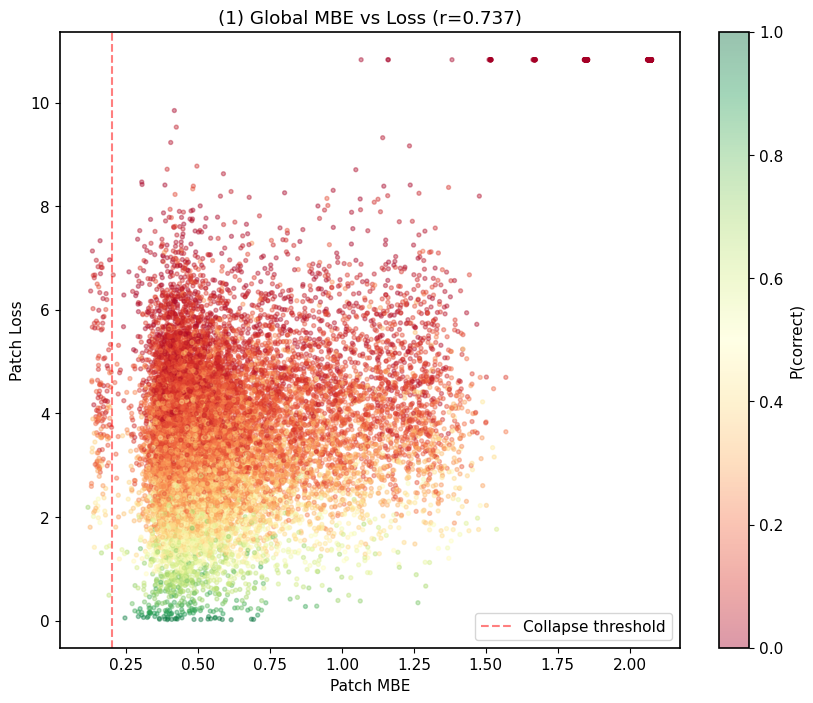

In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_all_patch_stats(log_dir):
    """Load and concatenate patch stats across all steps for global analysis."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    all_mbe, all_loss, all_prob, all_entropy, all_grad = [], [], [], [], []
    all_steps = []
    
    for f in patch_files:
        step = int(f.stem.split('step')[1])
        stats = torch.load(f)
        
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
        
        all_mbe.append(mbe)
        all_loss.append(loss)
        all_prob.append(prob)
        all_entropy.append(entropy)
        all_steps.append(np.full_like(mbe, step))
        
        # Grad if available
        if 'patch_grad' in stats and stats['patch_grad']:
            grad = torch.cat([p.flatten() for p in stats['patch_grad']]).float().numpy()
            # Match length
            min_len = min(len(mbe), len(grad))
            all_grad.append(grad[:min_len])
    
    return {
        'mbe': np.concatenate(all_mbe),
        'loss': np.concatenate(all_loss),
        'prob': np.concatenate(all_prob),
        'entropy': np.concatenate(all_entropy),
        'step': np.concatenate(all_steps),
        'grad': np.concatenate(all_grad) if all_grad else None,
    }

data = load_all_patch_stats("logs/log_run2")
print(f"Total patches across all steps: {len(data['mbe'])}")

# ============================================
# (1) Global MBE vs Loss
# ============================================
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

n_sample = min(20000, len(data['mbe']))
idx = np.random.choice(len(data['mbe']), n_sample, replace=False)

sc = ax1.scatter(data['mbe'][idx], data['loss'][idx], c=data['prob'][idx],
                 cmap='RdYlGn', alpha=0.4, s=8, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax1, label='P(correct)')
ax1.set_xlabel('Patch MBE')
ax1.set_ylabel('Patch Loss')
corr = np.corrcoef(data['mbe'], data['loss'])[0, 1]
ax1.set_title(f'(1) Global MBE vs Loss (r={corr:.3f})')
ax1.axvline(0.2, color='red', linestyle='--', alpha=0.5, label='Collapse threshold')
ax1.legend()

In [35]:
# ============================================
# (3b) Learning Efficiency: Gradient by Group (if available)
# ============================================
if data['grad'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Match lengths for grad
    min_len = len(data['grad'])
    
    # Recompute masks for grad-matched data
    groups_grad = {
        'Collapsed + Uncertain': (data['mbe'][:min_len] < 0.2) & (data['entropy'][:min_len] >= entropy_thresh),
        'Collapsed + Confident': (data['mbe'][:min_len] < 0.2) & (data['entropy'][:min_len] < entropy_thresh),
        'Healthy + Uncertain': (data['mbe'][:min_len] >= 0.2) & (data['entropy'][:min_len] >= entropy_thresh),
        'Healthy + Confident': (data['mbe'][:min_len] >= 0.2) & (data['entropy'][:min_len] < entropy_thresh),
    }
    
    # Gradient magnitude by group
    ax1 = axes[0]
    grads = [data['grad'][mask].mean() for mask in groups_grad.values()]
    bars = ax1.bar(range(4), grads, color=colors)
    ax1.set_xticks(range(4))
    ax1.set_xticklabels(list(groups_grad.keys()), fontsize=9, rotation=15)
    ax1.set_ylabel('Mean Gradient Magnitude')
    ax1.set_title('Learning Signal by Group')
    
    # "Learning efficiency" = gradient / loss (how much learning per unit error)
    ax2 = axes[1]
    losses_grad = [data['loss'][:min_len][mask].mean() for mask in groups_grad.values()]
    efficiency = [g / (l + 1e-6) for g, l in zip(grads, losses_grad)]
    bars = ax2.bar(range(4), efficiency, color=colors)
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(list(groups_grad.keys()), fontsize=9, rotation=15)
    ax2.set_ylabel('Gradient / Loss')
    ax2.set_title('Learning Efficiency (Gradient per Unit Error)')
    
    plt.tight_layout()
    plt.savefig('learning_efficiency.png', dpi=150)
    plt.show()
    
    print("\n=== Gradient Analysis ===")
    print(f"{'Group':<25} | {'Grad':>10} | {'Loss':>8} | {'Efficiency':>10}")
    print("-"*60)
    for name, mask in groups_grad.items():
        g = data['grad'][mask].mean()
        l = data['loss'][:min_len][mask].mean()
        print(f"{name:<25} | {g:>10.4f} | {l:>8.3f} | {g/l:>10.4f}")
else:
    print("\n⚠️ Gradient data not available yet - run new experiment with fixed code")


⚠️ Gradient data not available yet - run new experiment with fixed code


Total patches: 1,228,800


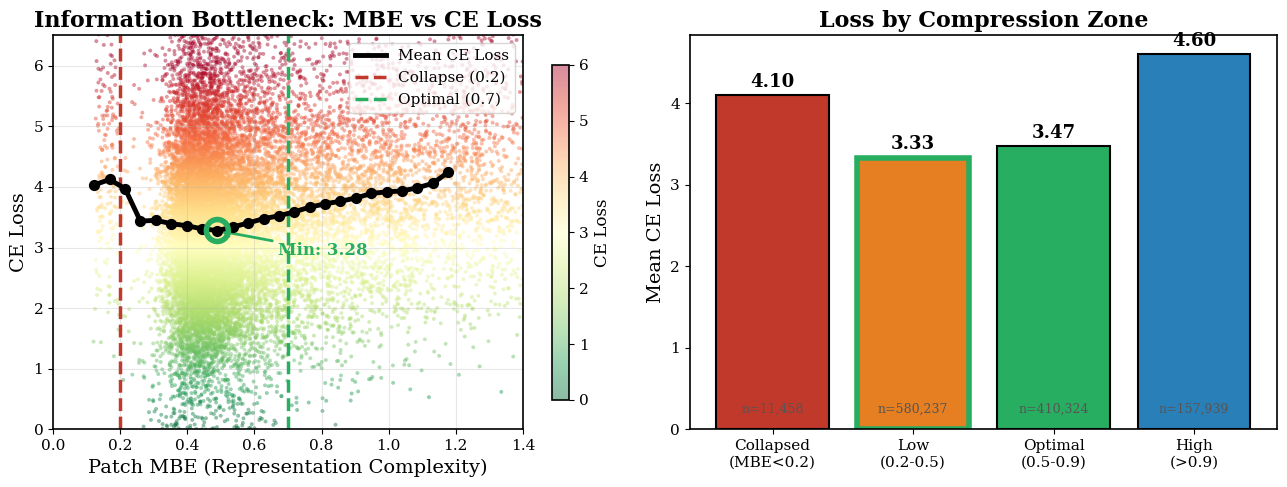


INFORMATION BOTTLENECK - CE LOSS ANALYSIS

Zone Analysis:
  Collapsed (MBE<0.2)      : Loss = 4.100 (n=11,458)
  Low (0.2-0.5)            : Loss = 3.333 (n=580,237)
  Optimal (0.5-0.9)        : Loss = 3.472 (n=410,324)
  High (>0.9)              : Loss = 4.602 (n=157,939)

→ Collapsed zone loss: 4.100
→ Optimal zone loss:   3.472
→ Loss REDUCTION:      0.627 (15.3%)

MBE-Loss correlation: r = 0.7371


In [49]:
# =====================================================================
# Information Bottleneck - Using CE LOSS (higher contrast)
# =====================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_all_patch_stats(log_dir):
    """Load and concatenate patch stats across all steps for global analysis."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    all_mbe, all_loss, all_prob, all_entropy = [], [], [], []
    
    for f in patch_files:
        stats = torch.load(f)
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
        
        all_mbe.append(mbe)
        all_loss.append(loss)
        all_prob.append(prob)
        all_entropy.append(entropy)
    
    return {
        'mbe': np.concatenate(all_mbe),
        'loss': np.concatenate(all_loss),
        'prob': np.concatenate(all_prob),
        'entropy': np.concatenate(all_entropy),
    }

# Load data
data = load_all_patch_stats("logs/log_run2")
print(f"Total patches: {len(data['mbe']):,}")

# =====================================================================
# Create figure with CE Loss (higher contrast than P(correct))
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# ----- LEFT: Main scatter with CE Loss -----
ax1 = axes[0]

# Subsample for visibility
n = min(20000, len(data['mbe']))
idx = np.random.choice(len(data['mbe']), n, replace=False)

# Scatter: MBE vs Loss, colored by loss (inverted - green=low loss=good)
loss_clip = np.clip(data['loss'][idx], 0, 8)  # Clip outliers
scatter = ax1.scatter(data['mbe'][idx], data['loss'][idx], 
                      c=loss_clip, cmap='RdYlGn_r',  # Reversed: green=low loss
                      s=8, alpha=0.45, vmin=0, vmax=6, edgecolors='none')

# Binned mean line for loss
bins = np.linspace(0.1, 1.2, 25)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_loss_means = []
for i in range(len(bins) - 1):
    mask = (data['mbe'] >= bins[i]) & (data['mbe'] < bins[i+1])
    bin_loss_means.append(data['loss'][mask].mean() if mask.sum() > 30 else np.nan)
bin_loss_means = np.array(bin_loss_means)
valid = ~np.isnan(bin_loss_means)

ax1.plot(bin_centers[valid], bin_loss_means[valid], 'k-', linewidth=3.5, 
         label='Mean CE Loss', zorder=5)
ax1.scatter(bin_centers[valid], bin_loss_means[valid], c='black', s=50, zorder=6)

# Mark key thresholds
ax1.axvline(0.2, color='#C0392B', linestyle='--', linewidth=2.5, label='Collapse (0.2)')
ax1.axvline(0.7, color='#27AE60', linestyle='--', linewidth=2.5, label='Optimal (0.7)')

# Find minimum loss point
min_idx = np.nanargmin(bin_loss_means)
ax1.scatter([bin_centers[min_idx]], [bin_loss_means[min_idx]], 
            s=250, facecolors='none', edgecolors='#27AE60', linewidths=4, zorder=7)
ax1.annotate(f'Min: {bin_loss_means[min_idx]:.2f}', 
             xy=(bin_centers[min_idx], bin_loss_means[min_idx]),
             xytext=(bin_centers[min_idx]+0.18, bin_loss_means[min_idx]-0.4),
             fontsize=12, fontweight='bold', color='#27AE60',
             arrowprops=dict(arrowstyle='->', color='#27AE60', lw=2))

ax1.set_xlabel('Patch MBE (Representation Complexity)', fontsize=14)
ax1.set_ylabel('CE Loss', fontsize=14)
ax1.set_title('Information Bottleneck: MBE vs CE Loss', fontsize=16, fontweight='bold')
ax1.set_xlim(0, 1.4)
ax1.set_ylim(0, 6.5)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax1, shrink=0.85)
cbar.set_label('CE Loss', fontsize=12)

# ----- RIGHT: Zone comparison bars (Loss) -----
ax2 = axes[1]

zones = ['Collapsed\n(MBE<0.2)', 'Low\n(0.2-0.5)', 'Optimal\n(0.5-0.9)', 'High\n(>0.9)']
bounds = [(0, 0.2), (0.2, 0.5), (0.5, 0.9), (0.9, 2.0)]
colors = ['#C0392B', '#E67E22', '#27AE60', '#2980B9']

losses, counts = [], []
for low, high in bounds:
    mask = (data['mbe'] >= low) & (data['mbe'] < high)
    losses.append(data['loss'][mask].mean() if mask.sum() > 0 else 0)
    counts.append(mask.sum())

bars = ax2.bar(range(4), losses, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(4))
ax2.set_xticklabels(zones, fontsize=11)
ax2.set_ylabel('Mean CE Loss', fontsize=14)
ax2.set_title('Loss by Compression Zone', fontsize=16, fontweight='bold')

# Value labels
for bar, loss, cnt in zip(bars, losses, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{loss:.2f}', ha='center', fontsize=13, fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2, 0.2, 
            f'n={cnt:,}', ha='center', fontsize=9, color='#555')

# Highlight optimal bar (lowest loss)
min_loss_idx = np.argmin(losses)
bars[min_loss_idx].set_edgecolor('#27AE60')
bars[min_loss_idx].set_linewidth(4)

plt.tight_layout()
plt.savefig('info_bottleneck_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Key finding
print(f"\n{'='*60}")
print("INFORMATION BOTTLENECK - CE LOSS ANALYSIS")
print(f"{'='*60}")
print(f"\nZone Analysis:")
for name, loss, cnt in zip(zones, losses, counts):
    name_clean = name.replace('\n', ' ')
    print(f"  {name_clean:<25}: Loss = {loss:.3f} (n={cnt:,})")

print(f"\n→ Collapsed zone loss: {losses[0]:.3f}")
print(f"→ Optimal zone loss:   {losses[2]:.3f}")
print(f"→ Loss REDUCTION:      {losses[0] - losses[2]:.3f} ({((losses[0] - losses[2]) / losses[0] * 100):.1f}%)")
print(f"\nMBE-Loss correlation: r = {np.corrcoef(data['mbe'], data['loss'])[0,1]:.4f}")


In [ ]:
# Ablation (I): 
# - continuously pre-train from xl ckpt, with 'bottleneck layer' surgically removed
# - if ppl remains on-par, we get layer pruning 
# - if ppl goes down, we verify that we obtain 'true bottleneck'



In [1]:
# --- Total hours required to pre-train on 10B tokens ---
tok_per_batch = (16 * 16 * 1024)
total_tok = 10 * 10**9
num_epoch = 1
steps = (num_epoch * total_tok) / tok_per_batch
ms_per_step = 5619 
total_hours = steps * ms_per_step / 1000 / 60 / 60

total_hours

59.54106648763021

In [55]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-run7.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out
print(run_info)
{k: loss_record[k][-1]for k in loss_record}

FineWeb 2-stage info-gain SoRL (Info gain vocab compression fraction=0.5) | no orthogonal init + attn_sweep


{'base_traj_loss': 3.2821,
 'cond_traj_loss (greedy)': 3.2921,
 'cond_traj_loss (search)': 3.2921,
 'abs_loss (greedy)': 0.0019,
 'abs_loss (search)': 0.0028,
 'greedy_adv': 0.1199,
 'info_gain (greedy)': -0.003,
 'info_gain (search)': -0.003,
 'util_rate (greedy)': 0.0947,
 'util_rate (search)': 0.0949,
 'K': 8.0}

In [25]:
# from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "2-stage-sorl-dynamics.gif", run_info, val_interval=125, fps=5)

Fixed axis limits: {'loss_min': 3.135855, 'loss_max': 11.366145, 'adv_min': -0.005, 'adv_max': 0.0235, 'info_min': -0.0164, 'info_max': 0.0157}
Generated frame 10/15
GIF saved to: 2-stage-sorl-dynamics.gif


In [72]:
# small_iblm_path = "logs/fineweb10B-gpt2-medium-iblm-w40.txt"
small_iblm_path = "logs/iblm-fineweb10B-gpt2-medium-20k.txt"
run_info, gpt2_small_iblm_record = extract_log_data(small_iblm_path)

small_path = "logs/fineweb10B-gpt2-medium-20k.txt"
_, gpt2_small_record = extract_log_data(small_path)

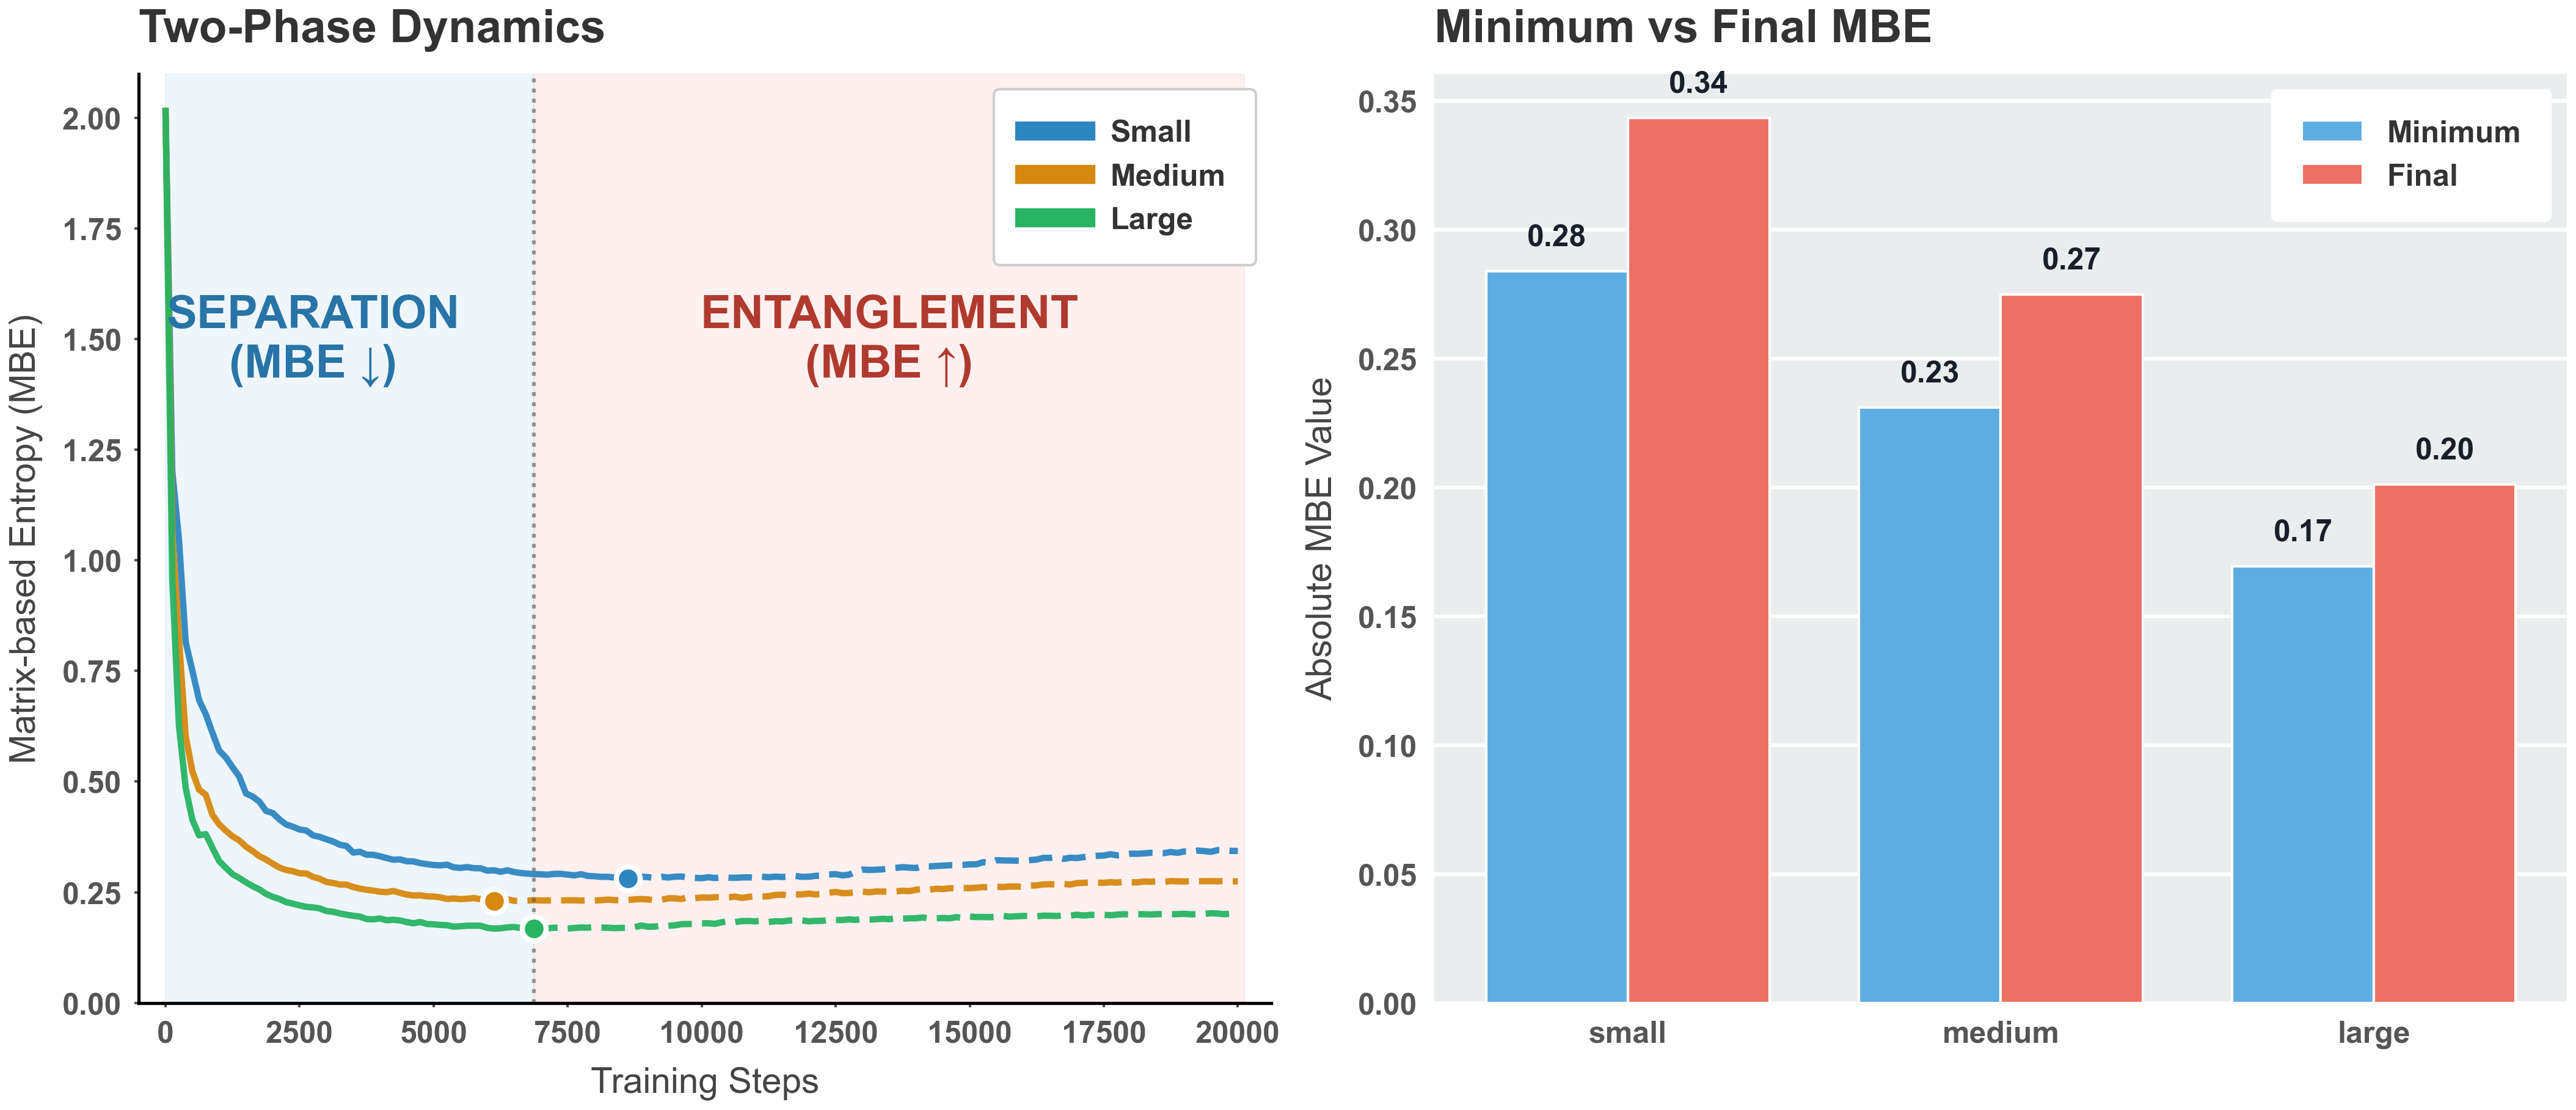

In [35]:
# ---- MBE dynamics plot ---
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

small_path = "logs/fineweb10B-gpt2-small-20k.txt"
_, gpt2_small_record = extract_log_data(small_path)

medium_path = "logs/fineweb10B-gpt2-medium-20k.txt"
_, gpt2_medium_record = extract_log_data(medium_path)

large_path = "logs/fineweb10B-gpt2-large-20k.txt"
_, gpt2_large_record = extract_log_data(large_path)

# --- Data ---
records = {
    'GPT2-small': gpt2_small_record,
    'GPT2-medium': gpt2_medium_record,
    'GPT2-large': gpt2_large_record,
}

val_interval = 125
models = ['GPT2-small', 'GPT2-medium', 'GPT2-large']
x = np.arange(len(models))
model_colors = ['#2E86C1', '#D68910', '#28B463'] # Stronger Blue, Orange, Green

c_sep = '#5DADE2' # Lighter blue for fill
c_ent = '#EC7063' # Lighter red for fill
c_gray = '#EAEDED'
c_text = '#17202A'

sep_mbe_end = [0.2838, 0.2310, 0.1694]
ent_mbe_end = [0.3433, 0.2747, 0.2010]

# --- SUPER-SIZE STYLE ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 24  # HUGE BASE FONT
plt.rcParams['axes.linewidth'] = 2.5 # Thicker axes
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(28, 12), dpi=150, constrained_layout=True)
fig.patch.set_facecolor('white')

# ============================================
# LEFT: MBE Trajectory
# ============================================
ax1 = axes[0]
ax1.set_facecolor('white')

all_mbe = [np.array(r['mbe']) for r in records.values()]
max_len = max(len(m) for m in all_mbe)
max_step = max_len * val_interval

# Plot Lines (Thicker)
for i, (model, record) in enumerate(records.items()):
    mbe = np.array(record['mbe'])
    steps = np.arange(len(mbe)) * val_interval
    min_idx = np.argmin(mbe)
    min_step = min_idx * val_interval
    min_val = mbe[min_idx]
    
    # Line width 5 for visibility
    ax1.plot(steps[:min_idx+1], mbe[:min_idx+1], linewidth=5, color=model_colors[i], alpha=0.95)
    ax1.plot(steps[min_idx:], mbe[min_idx:], linewidth=5, color=model_colors[i], alpha=0.95, linestyle='--')
    ax1.scatter([min_step], [min_val], s=350, color=model_colors[i], edgecolor='white', linewidth=4, zorder=5)

# Background Shading
large_mbe = np.array(records['GPT2-large']['mbe'])
transition_step = np.argmin(large_mbe) * val_interval
ax1.axvspan(0, transition_step, alpha=0.1, color=c_sep, zorder=0)
ax1.axvspan(transition_step, max_step, alpha=0.1, color=c_ent, zorder=0)
ax1.axvline(transition_step, color='#555555', linestyle=':', linewidth=3, alpha=0.6)

# Text Annotations (Massive)
ax1.text(transition_step * 0.4, 1.6, 'SEPARATION\n(MBE ↓)', 
         ha='center', va='top', fontsize=36, color='#2874A6', fontweight='heavy')
ax1.text(transition_step + (max_step - transition_step) * 0.5, 1.6, 'ENTANGLEMENT\n(MBE ↑)', 
         ha='center', va='top', fontsize=36, color='#B03A2E', fontweight='heavy')

# Legend
legend_elements = [
    Line2D([0], [0], color=model_colors[0], linewidth=15, label='Small'),
    Line2D([0], [0], color=model_colors[1], linewidth=15, label='Medium'),
    Line2D([0], [0], color=model_colors[2], linewidth=15, label='Large'),
]
# Simplified legend inside the plot
leg = ax1.legend(handles=legend_elements, loc='upper right', fontsize=24, frameon=True, framealpha=0.95, borderpad=1)
leg.get_frame().set_linewidth(2)

ax1.set_xlabel('Training Steps', fontsize=28, labelpad=15)
ax1.set_ylabel('Matrix-based Entropy (MBE)', fontsize=28, labelpad=15)
ax1.set_title('Two-Phase Dynamics', fontsize=36, pad=25, loc='left', fontweight='heavy')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(-500, max_step + 500)
ax1.set_ylim(0, 2.1)
ax1.tick_params(labelsize=24, pad=10)

# ============================================
# RIGHT: MBE Minimum vs Final
# ============================================
ax2 = axes[1]
ax2.set_facecolor(c_gray)
width_g = 0.38

rects1 = ax2.bar(x - width_g/2, sep_mbe_end, width_g, label='Minimum', color=c_sep, zorder=3, edgecolor='white', linewidth=2)
rects2 = ax2.bar(x + width_g/2, ent_mbe_end, width_g, label='Final', color=c_ent, zorder=3, edgecolor='white', linewidth=2)

ax2.grid(axis='y', color='white', linestyle='-', linewidth=3, zorder=0)
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('GPT2-', '') for m in models], fontweight='bold', fontsize=28) # Shorten names
ax2.set_ylabel('Absolute MBE Value', fontsize=28, labelpad=15)
ax2.set_title('Minimum vs Final MBE', fontsize=36, pad=25, loc='left', fontweight='heavy')
leg2 = ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=1, fontsize=24, borderpad=1)
leg2.get_frame().set_linewidth(0)

for spine in ax2.spines.values(): spine.set_visible(False)
ax2.tick_params(left=False, bottom=False, labelsize=24, pad=10)

# Values on bars
for rect in rects1:
    h = rect.get_height()
    ax2.text(rect.get_x() + rect.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', fontsize=24, fontweight='bold', color=c_text)
for rect in rects2:
    h = rect.get_height()
    ax2.text(rect.get_x() + rect.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', fontsize=24, fontweight='bold', color=c_text)

# plt.suptitle('GPT-2: MBE Phase Dynamics Scaling Laws', fontsize=40, fontweight='heavy', color='#1a1a1a', y=1.05)

plt.savefig('mbe_presentation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

Total patches: 1,228,800


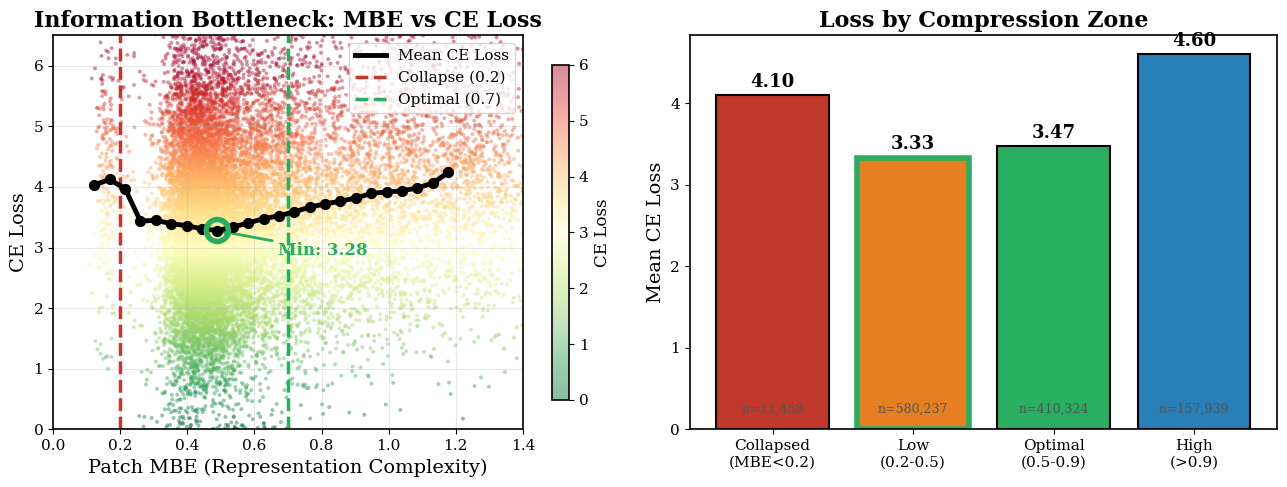


INFORMATION BOTTLENECK - CE LOSS ANALYSIS

Zone Analysis:
  Collapsed (MBE<0.2)      : Loss = 4.100 (n=11,458)
  Low (0.2-0.5)            : Loss = 3.333 (n=580,237)
  Optimal (0.5-0.9)        : Loss = 3.472 (n=410,324)
  High (>0.9)              : Loss = 4.602 (n=157,939)

→ Collapsed zone loss: 4.100
→ Optimal zone loss:   3.472
→ Loss REDUCTION:      0.627 (15.3%)

MBE-Loss correlation: r = 0.7371


In [51]:
# =====================================================================
# MBE vs Gradient Magnitude Analysis (log_run3)
# =====================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

def load_patch_stats_with_grad(log_dir):
    """Load patch stats including gradient magnitude."""
    patch_files = sorted(Path(log_dir).glob("patch_stats_step*.pt"))
    
    all_data = []
    for f in patch_files:
        step = int(f.stem.split('step')[1])
        stats = torch.load(f)
        
        # Check what keys are available
        if step == 0:
            print(f"Available keys: {list(stats.keys())}")
        
        mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
        loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
        prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
        entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
        
        # Gradient magnitude (if available)
        if 'patch_grad' in stats and stats['patch_grad'] and len(stats['patch_grad']) > 0:
            grad = torch.cat([p.flatten() for p in stats['patch_grad']]).float().numpy()
            # Match lengths if needed
            min_len = min(len(mbe), len(grad))
            mbe, loss, prob, entropy, grad = mbe[:min_len], loss[:min_len], prob[:min_len], entropy[:min_len], grad[:min_len]
        else:
            grad = None
            print(f"Warning: No gradient data at step {step}")
        
        all_data.append({
            'step': step,
            'mbe': mbe,
            'loss': loss,
            'prob': prob,
            'entropy': entropy,
            'grad': grad,
        })
    
    return all_data

# Load data from log_run3
all_data = load_patch_stats_with_grad("logs/log_run3")
print(f"\nLoaded {len(all_data)} steps")

# Check gradient availability
has_grad = [d['grad'] is not None for d in all_data]
print(f"Steps with gradient: {sum(has_grad)}/{len(has_grad)}")


Available keys: ['patch_mbe', 'patch_loss', 'patch_prob', 'patch_entropy', 'patch_grad']

Loaded 15 steps
Steps with gradient: 15/15


Analyzing 15 steps with gradient data


/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/3100149334.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_mbe_grad, _ = pearsonr(d['mbe'], d['grad'])
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/3100149334.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_mbe_prob, _ = pearsonr(d['mbe'], d['prob'])
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/3100149334.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_grad_prob, _ = pearsonr(d['grad'], d['prob'])


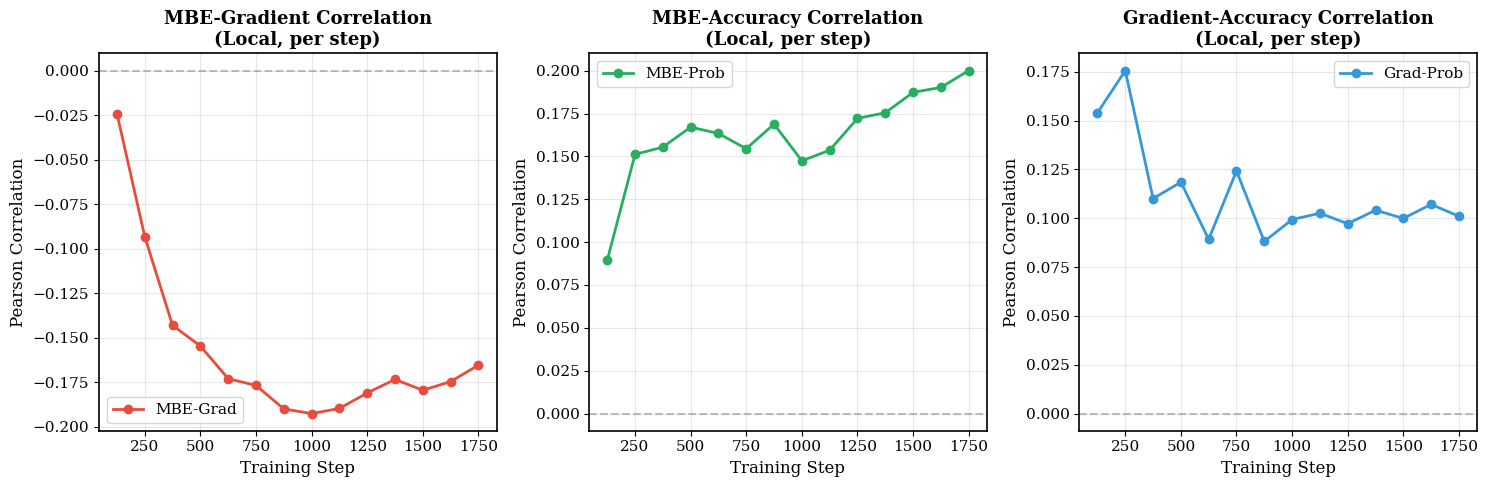


LOCAL CORRELATION SUMMARY (within each training step)
MBE-Gradient:  mean=nan, range=[nan, nan]
MBE-Accuracy:  mean=nan, range=[nan, nan]
Grad-Accuracy: mean=nan, range=[nan, nan]


In [52]:
# =====================================================================
# MBE vs Gradient Magnitude: Local & Global Correlations
# =====================================================================

# Filter to steps with gradient data
data_with_grad = [d for d in all_data if d['grad'] is not None]
print(f"Analyzing {len(data_with_grad)} steps with gradient data")

# =====================================================================
# (1) Per-Step Local Correlations: MBE-Grad, MBE-Prob, Grad-Prob
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

steps = [d['step'] for d in data_with_grad]
mbe_grad_corrs = []
mbe_prob_corrs = []
grad_prob_corrs = []

for d in data_with_grad:
    # Local correlations within each step
    r_mbe_grad, _ = pearsonr(d['mbe'], d['grad'])
    r_mbe_prob, _ = pearsonr(d['mbe'], d['prob'])
    r_grad_prob, _ = pearsonr(d['grad'], d['prob'])
    
    mbe_grad_corrs.append(r_mbe_grad)
    mbe_prob_corrs.append(r_mbe_prob)
    grad_prob_corrs.append(r_grad_prob)

# Plot correlations over training
ax1 = axes[0]
ax1.plot(steps, mbe_grad_corrs, 'o-', color='#E74C3C', linewidth=2, markersize=6, label='MBE-Grad')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Pearson Correlation', fontsize=12)
ax1.set_title('MBE-Gradient Correlation\n(Local, per step)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(steps, mbe_prob_corrs, 'o-', color='#27AE60', linewidth=2, markersize=6, label='MBE-Prob')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Pearson Correlation', fontsize=12)
ax2.set_title('MBE-Accuracy Correlation\n(Local, per step)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(steps, grad_prob_corrs, 'o-', color='#3498DB', linewidth=2, markersize=6, label='Grad-Prob')
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Training Step', fontsize=12)
ax3.set_ylabel('Pearson Correlation', fontsize=12)
ax3.set_title('Gradient-Accuracy Correlation\n(Local, per step)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mbe_grad_correlations.png', dpi=150)
plt.show()

# Summary
print("\n" + "="*60)
print("LOCAL CORRELATION SUMMARY (within each training step)")
print("="*60)
print(f"MBE-Gradient:  mean={np.mean(mbe_grad_corrs):.4f}, range=[{np.min(mbe_grad_corrs):.4f}, {np.max(mbe_grad_corrs):.4f}]")
print(f"MBE-Accuracy:  mean={np.mean(mbe_prob_corrs):.4f}, range=[{np.min(mbe_prob_corrs):.4f}, {np.max(mbe_prob_corrs):.4f}]")
print(f"Grad-Accuracy: mean={np.mean(grad_prob_corrs):.4f}, range=[{np.min(grad_prob_corrs):.4f}, {np.max(grad_prob_corrs):.4f}]")


In [63]:
# =====================================================================
# FIXED: Correlation Table - Local vs Global
# =====================================================================
import torch
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr

# Load data with proper structure
patch_files = sorted(Path("logs/log_run3").glob("patch_stats_step*.pt"))

# Per-step data for LOCAL correlations
local_mbe_loss, local_mbe_grad, local_mbe_entropy, local_mbe_prob = [], [], [], []
steps_list = []

# Accumulate for GLOBAL correlations
all_mbe, all_loss, all_grad, all_entropy, all_prob = [], [], [], [], []

for f in patch_files:
    step = int(f.stem.split('step')[1])
    stats = torch.load(f)
    
    mbe = torch.cat([p.flatten() for p in stats['patch_mbe']]).float().numpy()
    loss = torch.cat([p.flatten() for p in stats['patch_loss']]).float().numpy()
    prob = torch.cat([p.flatten() for p in stats['patch_prob']]).float().numpy()
    entropy = torch.cat([p.flatten() for p in stats['patch_entropy']]).float().numpy()
    
    # Handle gradient
    grad = None
    if 'patch_grad' in stats and stats['patch_grad'] and len(stats['patch_grad']) > 0:
        grad = torch.cat([p.flatten() for p in stats['patch_grad']]).float().numpy()
        min_len = min(len(mbe), len(grad))
        mbe_g, loss_g, prob_g, entropy_g, grad_g = mbe[:min_len], loss[:min_len], prob[:min_len], entropy[:min_len], grad[:min_len]
    else:
        mbe_g, loss_g, prob_g, entropy_g, grad_g = mbe, loss, prob, entropy, None
    
    # LOCAL correlations for this step
    steps_list.append(step)
    local_mbe_loss.append(pearsonr(mbe, loss)[0])
    local_mbe_entropy.append(pearsonr(mbe, entropy)[0])
    local_mbe_prob.append(pearsonr(mbe, prob)[0])
    if grad_g is not None:
        local_mbe_grad.append(pearsonr(mbe_g, grad_g)[0])
    
    # Accumulate for GLOBAL
    all_mbe.append(mbe_g if grad_g is not None else mbe)
    all_loss.append(loss_g if grad_g is not None else loss)
    all_entropy.append(entropy_g if grad_g is not None else entropy)
    all_prob.append(prob_g if grad_g is not None else prob)
    if grad_g is not None:
        all_grad.append(grad_g)

# Concatenate for GLOBAL
g_mbe = np.concatenate(all_mbe)
g_loss = np.concatenate(all_loss)
g_entropy = np.concatenate(all_entropy)
g_prob = np.concatenate(all_prob)
g_grad = np.concatenate(all_grad) if all_grad else None

# GLOBAL correlations
global_mbe_loss = pearsonr(g_mbe, g_loss)[0]
global_mbe_entropy = pearsonr(g_mbe, g_entropy)[0]
global_mbe_prob = pearsonr(g_mbe, g_prob)[0]
global_mbe_grad = pearsonr(g_mbe, g_grad)[0] if g_grad is not None else np.nan


# LOCAL means
local_mean_loss = np.mean(local_mbe_loss[1:])
local_mean_entropy = np.mean(local_mbe_entropy[1:])
local_mean_prob = np.mean(local_mbe_prob[1:])
local_mean_grad = np.mean(local_mbe_grad[1:]) if local_mbe_grad else np.nan


/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/2547370781.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  local_mbe_loss.append(pearsonr(mbe, loss)[0])
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/2547370781.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  local_mbe_entropy.append(pearsonr(mbe, entropy)[0])
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/2547370781.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  local_mbe_prob.append(pearsonr(mbe, prob)[0])
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_10462/2547370781.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  local_mbe_grad.append(pearsonr(mbe_g, grad_g)[0])


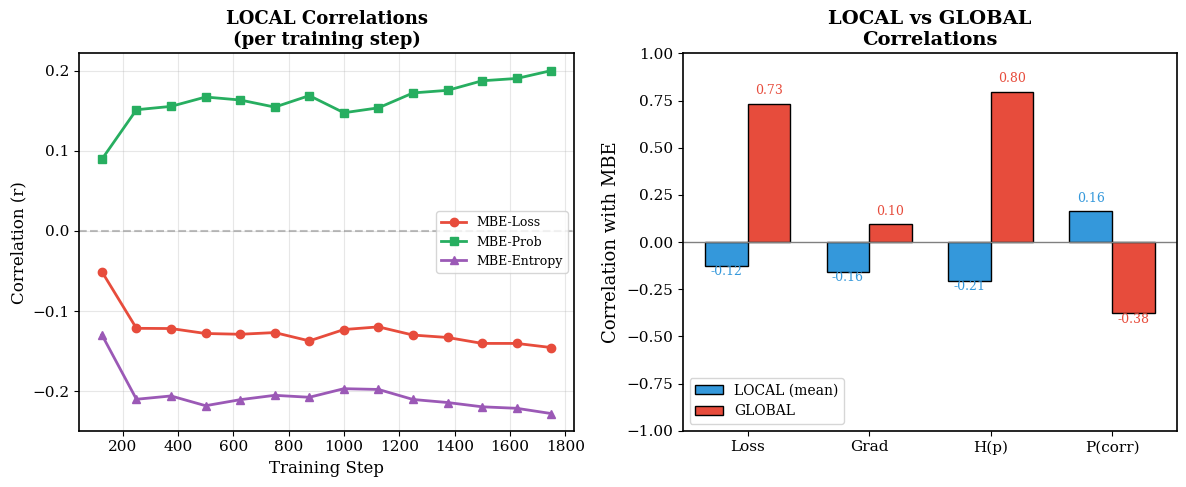

In [62]:
# =====================================================================
# Visualization: Just 2 figures (remove 3rd)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Local correlations over training steps
ax1 = axes[0]
ax1.plot(steps, local_mbe_loss, 'o-', color='#E74C3C', lw=2, ms=6, label='MBE-Loss')
ax1.plot(steps, local_mbe_prob, 's-', color='#27AE60', lw=2, ms=6, label='MBE-Prob')
ax1.plot(steps, local_mbe_entropy, '^-', color='#9B59B6', lw=2, ms=6, label='MBE-Entropy')
ax1.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Correlation (r)', fontsize=12)
ax1.set_title('LOCAL Correlations\n(per training step)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# (b) Bar chart: Local vs Global
ax2 = axes[1]
names = ['Loss', 'Grad', 'H(p)', 'P(corr)']
local_vals = [local_mean_loss, local_mean_grad, local_mean_entropy, local_mean_prob]
global_vals = [global_mbe_loss, global_mbe_grad, global_mbe_entropy, global_mbe_prob]

x = np.arange(4)
w = 0.35
bars1 = ax2.bar(x - w/2, local_vals, w, label='LOCAL (mean)', color='#3498DB', edgecolor='black')
bars2 = ax2.bar(x + w/2, global_vals, w, label='GLOBAL', color='#E74C3C', edgecolor='black')
ax2.axhline(0, color='gray', ls='-', lw=1)
ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=11)
ax2.set_ylabel('Correlation with MBE', fontsize=13)
ax2.set_title('LOCAL vs GLOBAL\nCorrelations', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(-1, 1)

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05 * np.sign(h), f'{h:.2f}', 
             ha='center', fontsize=9, color='#3498DB')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05 * np.sign(h), f'{h:.2f}', 
             ha='center', fontsize=9, color='#E74C3C')

plt.tight_layout()
plt.savefig('mbe_local_global_table.png', dpi=150)
plt.show()

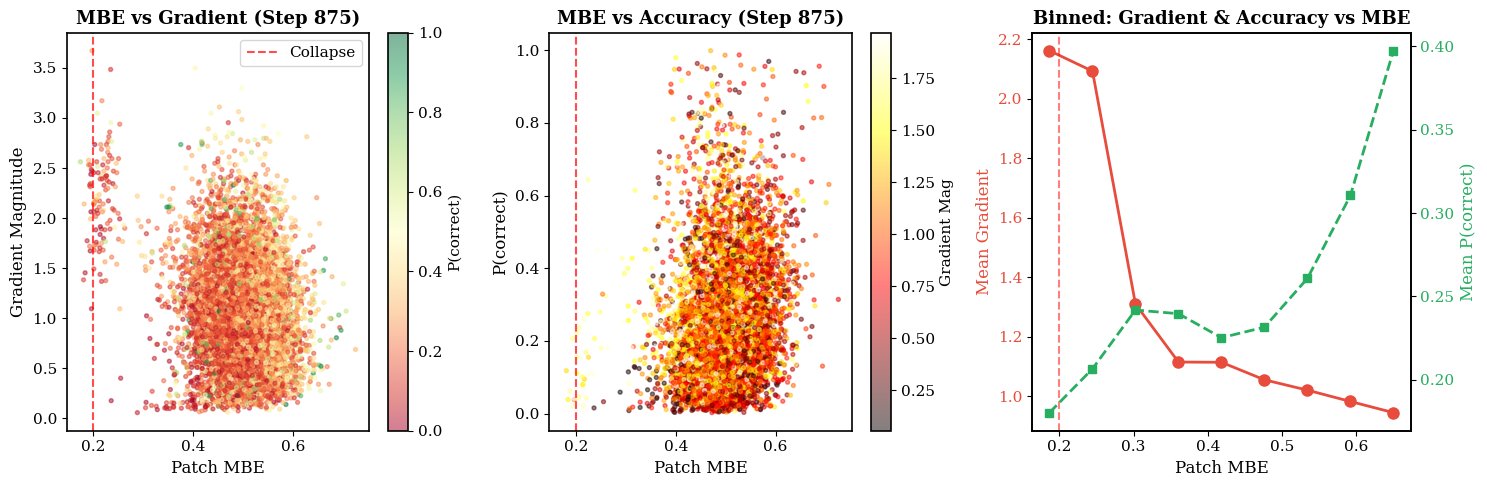


Step 875 correlations:
  MBE-Gradient: r = -0.1900
  MBE-Accuracy: r = 0.1688


In [53]:
# =====================================================================
# (2) MBE vs Gradient Scatter (single step visualization)
# =====================================================================

# Pick a middle step for visualization
mid_idx = len(data_with_grad) // 2
d = data_with_grad[mid_idx]
step = d['step']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subsample for visibility
n = min(10000, len(d['mbe']))
idx = np.random.choice(len(d['mbe']), n, replace=False)

# (a) MBE vs Gradient, colored by P(correct)
ax1 = axes[0]
sc = ax1.scatter(d['mbe'][idx], d['grad'][idx], c=d['prob'][idx], 
                 cmap='RdYlGn', s=8, alpha=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax1, label='P(correct)')
ax1.set_xlabel('Patch MBE', fontsize=12)
ax1.set_ylabel('Gradient Magnitude', fontsize=12)
ax1.set_title(f'MBE vs Gradient (Step {step})', fontsize=13, fontweight='bold')
ax1.axvline(0.2, color='red', linestyle='--', alpha=0.7, label='Collapse')
ax1.legend()

# (b) MBE vs P(correct), colored by Gradient
ax2 = axes[1]
grad_clip = np.clip(d['grad'][idx], 0, np.percentile(d['grad'], 95))
sc2 = ax2.scatter(d['mbe'][idx], d['prob'][idx], c=grad_clip, 
                  cmap='hot', s=8, alpha=0.5)
plt.colorbar(sc2, ax=ax2, label='Gradient Mag')
ax2.set_xlabel('Patch MBE', fontsize=12)
ax2.set_ylabel('P(correct)', fontsize=12)
ax2.set_title(f'MBE vs Accuracy (Step {step})', fontsize=13, fontweight='bold')
ax2.axvline(0.2, color='red', linestyle='--', alpha=0.7)

# (c) Binned analysis: Mean Gradient by MBE bin
ax3 = axes[2]
bins = np.linspace(0.1, 1.2, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_grads = []
bin_probs = []
for i in range(len(bins) - 1):
    mask = (d['mbe'] >= bins[i]) & (d['mbe'] < bins[i+1])
    if mask.sum() > 30:
        bin_grads.append(d['grad'][mask].mean())
        bin_probs.append(d['prob'][mask].mean())
    else:
        bin_grads.append(np.nan)
        bin_probs.append(np.nan)

ax3.plot(bin_centers, bin_grads, 'o-', color='#E74C3C', linewidth=2, markersize=8, label='Mean Gradient')
ax3_twin = ax3.twinx()
ax3_twin.plot(bin_centers, bin_probs, 's--', color='#27AE60', linewidth=2, markersize=6, label='Mean P(correct)')
ax3.set_xlabel('Patch MBE', fontsize=12)
ax3.set_ylabel('Mean Gradient', fontsize=12, color='#E74C3C')
ax3_twin.set_ylabel('Mean P(correct)', fontsize=12, color='#27AE60')
ax3.set_title(f'Binned: Gradient & Accuracy vs MBE', fontsize=13, fontweight='bold')
ax3.axvline(0.2, color='red', linestyle='--', alpha=0.5)
ax3.tick_params(axis='y', labelcolor='#E74C3C')
ax3_twin.tick_params(axis='y', labelcolor='#27AE60')

plt.tight_layout()
plt.savefig('mbe_grad_scatter.png', dpi=150)
plt.show()

# Correlation at this step
r_mg, _ = pearsonr(d['mbe'], d['grad'])
r_mp, _ = pearsonr(d['mbe'], d['prob'])
print(f"\nStep {step} correlations:")
print(f"  MBE-Gradient: r = {r_mg:.4f}")
print(f"  MBE-Accuracy: r = {r_mp:.4f}")


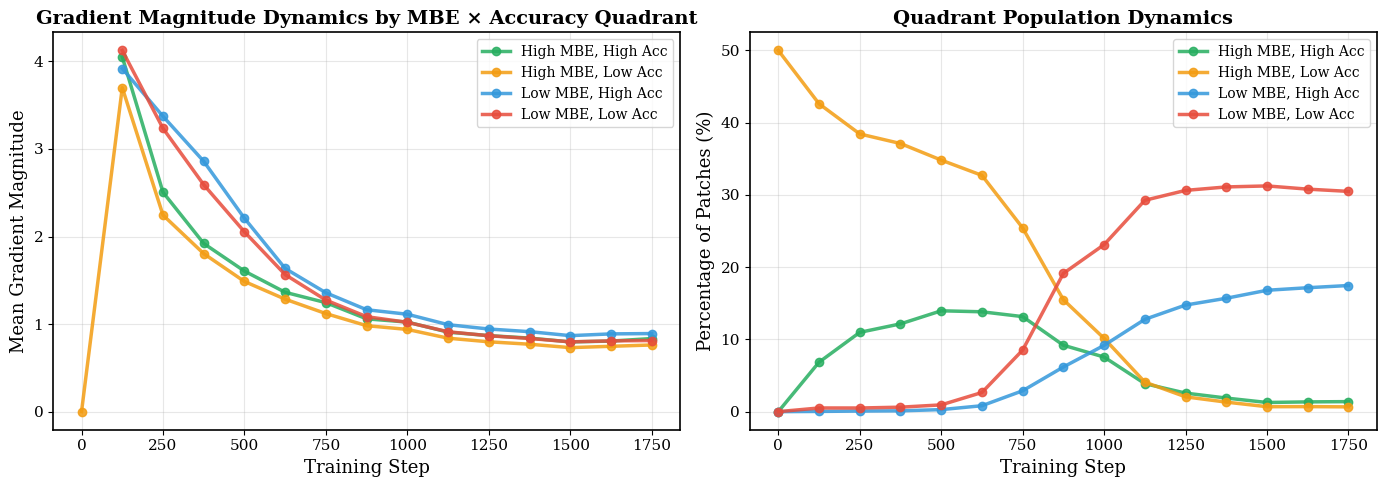


QUADRANT GRADIENT SUMMARY
Quadrant                  |   Start Grad |     End Grad |     Change
----------------------------------------------------------------------
High MBE, High Acc        |          nan |       0.8348 |       +nan
High MBE, Low Acc         |       0.0000 |       0.7614 |    +0.7614
Low MBE, High Acc         |          nan |       0.8918 |       +nan
Low MBE, Low Acc          |          nan |       0.8124 |       +nan

KEY INSIGHT
Expected pattern:
  • High MBE, High Acc → LOWEST gradient (already learned, well-compressed)
  • Low MBE, Low Acc   → HIGHEST gradient (struggling, over-compressed)
  • The gap between quadrants should reveal learning dynamics


In [55]:
# =====================================================================
# (4) Gradient Dynamics Over Training by Quadrant (Line Plot)
# =====================================================================

mbe_thresh = 0.5
prob_thresh = 0.3

# Collect per-step stats for each quadrant
quadrant_names = ['High MBE, High Acc', 'High MBE, Low Acc', 'Low MBE, High Acc', 'Low MBE, Low Acc']
colors = ['#27AE60', '#F39C12', '#3498DB', '#E74C3C']

steps_list = []
quad_grad_series = {name: [] for name in quadrant_names}
quad_count_series = {name: [] for name in quadrant_names}

for d in data_with_grad:
    steps_list.append(d['step'])
    mbe, prob, grad = d['mbe'], d['prob'], d['grad']
    
    masks = [
        (mbe >= mbe_thresh) & (prob >= prob_thresh),  # High MBE, High Acc
        (mbe >= mbe_thresh) & (prob < prob_thresh),   # High MBE, Low Acc
        (mbe < mbe_thresh) & (prob >= prob_thresh),   # Low MBE, High Acc
        (mbe < mbe_thresh) & (prob < prob_thresh),    # Low MBE, Low Acc
    ]
    
    for name, mask in zip(quadrant_names, masks):
        quad_grad_series[name].append(grad[mask].mean() if mask.sum() > 0 else np.nan)
        quad_count_series[name].append(mask.sum())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Gradient magnitude over training by quadrant
ax1 = axes[0]
for name, color in zip(quadrant_names, colors):
    ax1.plot(steps_list, quad_grad_series[name], 'o-', color=color, 
             linewidth=2.5, markersize=6, label=name, alpha=0.85)

ax1.set_xlabel('Training Step', fontsize=13)
ax1.set_ylabel('Mean Gradient Magnitude', fontsize=13)
ax1.set_title('Gradient Magnitude Dynamics by MBE × Accuracy Quadrant', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3)

# (b) Quadrant population over training
ax2 = axes[1]
for name, color in zip(quadrant_names, colors):
    pct = 100 * np.array(quad_count_series[name]) / sum(quad_count_series[quadrant_names[0]])
    ax2.plot(steps_list, pct, 'o-', color=color, linewidth=2.5, markersize=6, label=name, alpha=0.85)

ax2.set_xlabel('Training Step', fontsize=13)
ax2.set_ylabel('Percentage of Patches (%)', fontsize=13)
ax2.set_title('Quadrant Population Dynamics', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quadrant_gradient_dynamics.png', dpi=150)
plt.show()

# Summary table
print("\n" + "="*70)
print("QUADRANT GRADIENT SUMMARY")
print("="*70)
print(f"{'Quadrant':<25} | {'Start Grad':>12} | {'End Grad':>12} | {'Change':>10}")
print("-"*70)
for name in quadrant_names:
    start = quad_grad_series[name][0]
    end = quad_grad_series[name][-1]
    change = end - start
    print(f"{name:<25} | {start:>12.4f} | {end:>12.4f} | {change:>+10.4f}")

print("\n" + "="*70)
print("KEY INSIGHT")
print("="*70)
print("Expected pattern:")
print("  • High MBE, High Acc → LOWEST gradient (already learned, well-compressed)")
print("  • Low MBE, Low Acc   → HIGHEST gradient (struggling, over-compressed)")
print("  • The gap between quadrants should reveal learning dynamics")


In [ ]:
def mbe_equity_loss(patch_mbe, target_floor=0.35):
    """
    Dual objective:
    1. Global: mean → target_floor (compress, but not too much)
    2. Local: var → 0 (no patch left behind)
    """
    mbe_flat = patch_mbe.flatten()
    mean_mbe = mbe_flat.mean()
    
    # Global: penalize if mean is BELOW floor (under-compressed is fine)
    global_floor_loss = F.relu(target_floor - mean_mbe)
    
    # Local: variance minimization (equity)
    equity_loss = mbe_flat.var()
    
    return global_floor_loss + λ_equity * equity_loss